<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/%F0%9F%8C%9F_General_Mental_Health_%26_Lifestyle_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌟 General Mental Health & Lifestyle Dataset

# Introduction and Insights

Dataset, comprising 2000 entries across 12 features, offers a comprehensive look into various aspects of general mental health and lifestyle, with no missing values or duplicates, ensuring data integrity. It includes a mix of numerical features like 'sleep_hours', 'screen_time', 'exercise_minutes', 'fatigue_level', 'mood_score', and 'stress_level', alongside categorical factors such as 'diet_quality' and 'weather'. Initial univariate analysis reveals diverse distributions; 'sleep_hours' averages around 7 hours, while 'screen_time' and 'fatigue_level' are typically near 5 units. 'Exercise_minutes' shows a right-skewed distribution, indicating many individuals exercise for short durations with a few engaging in much longer sessions. 'Mood_score' tends to be high, with many individuals reporting scores near the maximum of 10, whereas 'stress_level' is often reported at its minimum, suggesting a general tendency towards lower perceived stress in the sample, though some high stress instances exist. Categorical features like 'diet_quality' are fairly distributed among 'average', 'good', and 'poor', with 'average' being the most common, and 'weather' categories are almost equally represented. Bivariate analysis highlights several key relationships. A strong positive correlation exists between 'sleep_hours' and 'mood_score', and a strong negative correlation with 'stress_level', suggesting adequate sleep is vital for mental well-being. Conversely, 'fatigue_level' shows a significant negative correlation with 'mood_score' and a positive correlation with 'stress_level', underscoring the detrimental impact of fatigue. 'Screen_time' exhibits a slight negative association with mood and a slight positive one with stress, while 'exercise_minutes' positively influences mood and negatively impacts stress, albeit with weaker correlations. The number of 'daily_pending_tasks' and 'interruptions' also appears to increase 'stress_level'. Furthermore, 'diet_quality' plays a role, with individuals reporting 'good' diets generally showing higher 'mood_score' and lower 'stress_level' compared to those with 'average' or 'poor' diets. 'Weather' conditions also subtly influence mood, with 'sunny' days potentially correlating with slightly better mood scores. These insights collectively point to the interconnectedness of lifestyle factors like sleep, exercise, diet, and screen time with an individual's mood and stress levels, offering valuable preliminary understandings for mental health interventions.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mabubakrsiddiq/general-mental-health-and-lifestyle-dataset

# Unziping the downloaded file
!unzip general-mental-health-and-lifestyle-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mabubakrsiddiq/general-mental-health-and-lifestyle-dataset
License(s): apache-2.0
  0% 0.00/122k [00:00<?, ?B/s]
100% 122k/122k [00:00<00:00, 347MB/s]
Archive:  general-mental-health-and-lifestyle-dataset.zip
  inflating: synthetic_mental_health_dataset.csv  


# Data Inspection

In [5]:
df = pd.read_csv('synthetic_mental_health_dataset.csv')
df.head(11)

,sleep_hours,screen_time,exercise_minutes,daily_pending_tasks,interruptions,fatigue_level,social_hours,coffee_cups,diet_quality,weather,mood_score,stress_level
0,7.745071,3.649643,13.272466,1,5,4.179955,2.448854,1,average,snowy,9.171062,1.000000
1,6.792604,4.710963,1.785436,3,6,4.883679,1.330623,3,good,sunny,5.706491,3.558516
2,7.971533,3.415160,71.843325,4,10,4.207812,2.134120,0,poor,cloudy,10.000000,2.971450
3,9.284545,4.384077,14.596656,2,4,3.362592,1.857070,0,good,sunny,8.385038,1.000000
4,6.648770,1.212771,19.048010,3,5,6.229107,2.642980,1,poor,rainy,10.000000,1.639047
5,6.648795,5.426587,5.399719,3,3,4.702907,2.141541,0,poor,cloudy,5.916326,1.032066
6,9.368819,5.002411,13.213526,3,3,4.821121,2.286157,1,average,sunny,8.374238,1.000000
7,8.151152,3.365823,11.212558,2,8,0.000000,0.974128,1,good,sunny,9.375238,1.000000
8,6.295788,6.318491,1.556979,3,3,4.547024,0.721868,0,average,snowy,4.838739,1.573465
9,7.813840,6.875140,2.244578,1,7,2.846783,2.070628,2,average,rainy,6.447029,1.000000


In [6]:
df.tail(11)

,sleep_hours,screen_time,exercise_minutes,daily_pending_tasks,interruptions,fatigue_level,social_hours,coffee_cups,diet_quality,weather,mood_score,stress_level
1989,7.647884,3.450770,14.688990,4,4,5.556519,3.364992,0,good,cloudy,8.477498,2.415693
1990,8.200614,1.621634,22.607867,2,5,6.198067,0.699879,2,good,rainy,10.000000,1.000000
1991,8.131437,4.057473,30.148088,2,6,4.385124,1.802359,2,poor,cloudy,10.000000,1.000000
1992,8.783370,1.049024,2.808580,6,5,2.591160,1.267017,3,poor,rainy,8.541434,3.797924
1993,8.062456,6.502199,18.373732,1,2,8.774557,1.073928,0,good,rainy,8.282111,1.000000
1994,7.527172,0.869834,0.697998,2,5,2.321076,3.135044,0,poor,snowy,7.896629,1.000000
1995,8.605225,5.056915,13.765823,3,3,8.362518,3.113966,2,poor,snowy,8.765375,1.086619
1996,6.960218,0.844376,3.364650,2,7,4.869502,3.775442,0,good,rainy,7.796204,1.000000
1997,5.677188,4.359404,4.040437,6,1,7.494879,2.678349,0,average,snowy,4.701231,3.733475
1998,6.755400,8.286756,9.084104,3,1,5.045832,1.955221,2,average,cloudy,6.170718,1.000000


In [7]:
df.shape

(2000, 12)

In [8]:
df.columns

Index(['sleep_hours', 'screen_time', 'exercise_minutes', 'daily_pending_tasks',
       'interruptions', 'fatigue_level', 'social_hours', 'coffee_cups',
       'diet_quality', 'weather', 'mood_score', 'stress_level'],
      dtype='object')

In [9]:
df.dtypes

,0
sleep_hours,float64
screen_time,float64
exercise_minutes,float64
daily_pending_tasks,int64
interruptions,int64
fatigue_level,float64
social_hours,float64
coffee_cups,int64
diet_quality,object
weather,object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sleep_hours          2000 non-null   float64
 1   screen_time          2000 non-null   float64
 2   exercise_minutes     2000 non-null   float64
 3   daily_pending_tasks  2000 non-null   int64  
 4   interruptions        2000 non-null   int64  
 5   fatigue_level        2000 non-null   float64
 6   social_hours         2000 non-null   float64
 7   coffee_cups          2000 non-null   int64  
 8   diet_quality         2000 non-null   object 
 9   weather              2000 non-null   object 
 10  mood_score           2000 non-null   float64
 11  stress_level         2000 non-null   float64
dtypes: float64(7), int64(3), object(2)
memory usage: 187.6+ KB


In [12]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sleep_hours,2000.0,NaN,NaN,NaN,7.067237,1.481299,2.138099,6.066007,7.067037,8.024466,12.0
screen_time,2000.0,NaN,NaN,NaN,4.990009,2.002973,0.0,3.581748,4.999893,6.331087,12.852475
exercise_minutes,2000.0,NaN,NaN,NaN,19.868516,20.071066,0.004821,5.580022,13.289737,28.118005,150.504069
daily_pending_tasks,2000.0,NaN,NaN,NaN,2.9485,1.725206,0.0,2.0,3.0,4.0,10.0
interruptions,2000.0,NaN,NaN,NaN,5.131,2.278472,0.0,3.0,5.0,7.0,15.0
fatigue_level,2000.0,NaN,NaN,NaN,4.996769,2.00043,0.0,3.647335,4.956565,6.320355,10.0
social_hours,2000.0,NaN,NaN,NaN,2.001369,0.959934,0.0,1.304384,1.996521,2.653096,5.505871
coffee_cups,2000.0,NaN,NaN,NaN,0.9895,1.012869,0.0,0.0,1.0,2.0,6.0
diet_quality,2000,3,average,998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,2000,4,sunny,534,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.isnull().sum()

,0
sleep_hours,0
screen_time,0
exercise_minutes,0
daily_pending_tasks,0
interruptions,0
fatigue_level,0
social_hours,0
coffee_cups,0
diet_quality,0
weather,0


In [15]:
df.duplicated().sum()

np.int64(0)

# Feature Engineering

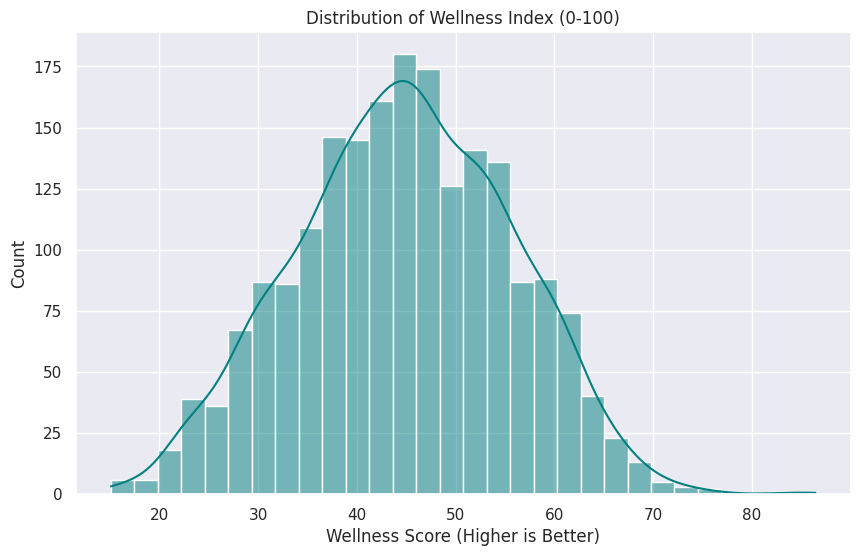

Top 5 Healthiest Profiles:
      Wellness_Index  sleep_hours  exercise_minutes diet_quality
1453       86.412154    10.902525        130.873449         good
489        83.561447     8.322460        121.257177         good
880        76.100710    10.790399         31.220885         good
716        74.981526     7.171341        146.780011         good
1910       73.764049     9.598772         54.612678         good


In [22]:
from sklearn.preprocessing import MinMaxScaler

# 1. Create a copy of the dataframe
df_eng = df.copy()

# 2. Encode 'Diet_Quality' (Turn text into numbers)
# We use Ordinal Encoding because Order Matters (Poor < Average < Good)
diet_map = {'poor': 0, 'average': 1, 'good': 2}
df_eng['diet_score'] = df_eng['diet_quality'].map(diet_map)

# 3. Normalize Columns (Scale everything to 0-1 range)
# This is crucial so that '120 minutes of exercise' doesn't overpower '8 hours of sleep'
scaler = MinMaxScaler()

cols_to_scale = ['sleep_hours', 'exercise_minutes', 'diet_score', 'screen_time']
df_scaled = pd.DataFrame(scaler.fit_transform(df_eng[cols_to_scale]), columns=cols_to_scale)

# 4. Calculate Wellness Score
# Formula: (Sleep + Exercise + Diet) - Screen_Time
# Note: Screen Time is BAD, so we subtract it (or add (1 - Screen_Time))
# We equate:
#   + Sleep (Good)
#   + Exercise (Good)
#   + Diet (Good)
#   + (1 - Screen_Time) (Less screen is Good)

df_eng['Wellness_Index'] = (
    df_scaled['sleep_hours'] +
    df_scaled['exercise_minutes'] +
    df_scaled['diet_score'] +
    (1 - df_scaled['screen_time']) # Invert screen time so Low Screen = High Score
) / 4 * 100 # Average and scale to 0-100

# 5. Visualize the Result
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_eng['Wellness_Index'], kde=True, color='teal')
plt.title('Distribution of Wellness Index (0-100)')
plt.xlabel('Wellness Score (Higher is Better)')
plt.show()

print("Top 5 Healthiest Profiles:")
print(df_eng[['Wellness_Index', 'sleep_hours', 'exercise_minutes', 'diet_quality']].sort_values(by='Wellness_Index', ascending=False).head())

# Statistical Hypothesis Testing

--- ANOVA Test Results ---
F-Statistic: 0.56
P-Value: 0.5722146562

❌ Result: No Significant Difference.
Conclusion: Diet Quality does NOT affect Stress Levels (Fail to Reject Null Hypothesis).


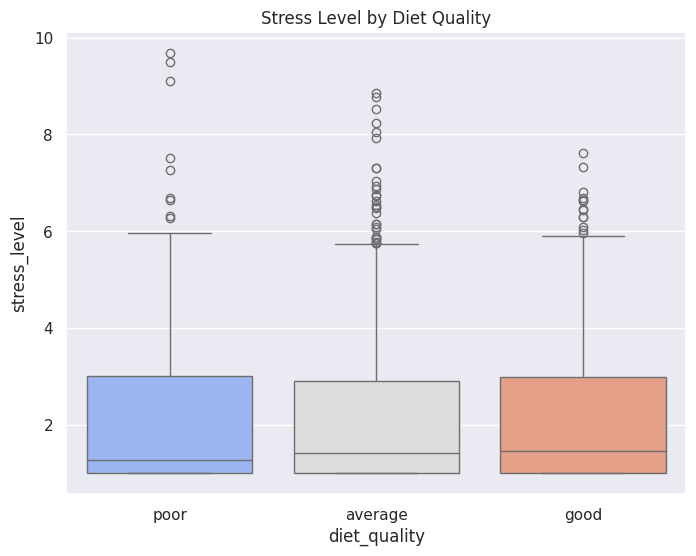

In [23]:
from scipy.stats import f_oneway

# 1. Separate the Data into Groups
# We get the 'Stress_Level' for each Diet Type
stress_poor = df[df['diet_quality'] == 'poor']['stress_level']
stress_avg = df[df['diet_quality'] == 'average']['stress_level']
stress_good = df[df['diet_quality'] == 'good']['stress_level']

# 2. Run the ANOVA Test
stat, p_value = f_oneway(stress_poor, stress_avg, stress_good)

print(f"--- ANOVA Test Results ---")
print(f"F-Statistic: {stat:.2f}")
print(f"P-Value: {p_value:.10f}") # 10 decimal places to see very small numbers

# 3. Interpretation
alpha = 0.05 # Standard 5% significance level
if p_value < alpha:
    print("\n✅ Result: Significant Difference Found!")
    print("Conclusion: Diet Quality DOES affect Stress Levels (Reject Null Hypothesis).")
else:
    print("\n❌ Result: No Significant Difference.")
    print("Conclusion: Diet Quality does NOT affect Stress Levels (Fail to Reject Null Hypothesis).")

# 4. Visual Proof (Boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='diet_quality', y='stress_level', data=df, order=['poor', 'average', 'good'], palette='coolwarm')
plt.title('Stress Level by Diet Quality')
plt.show()

# Univariate Analysis

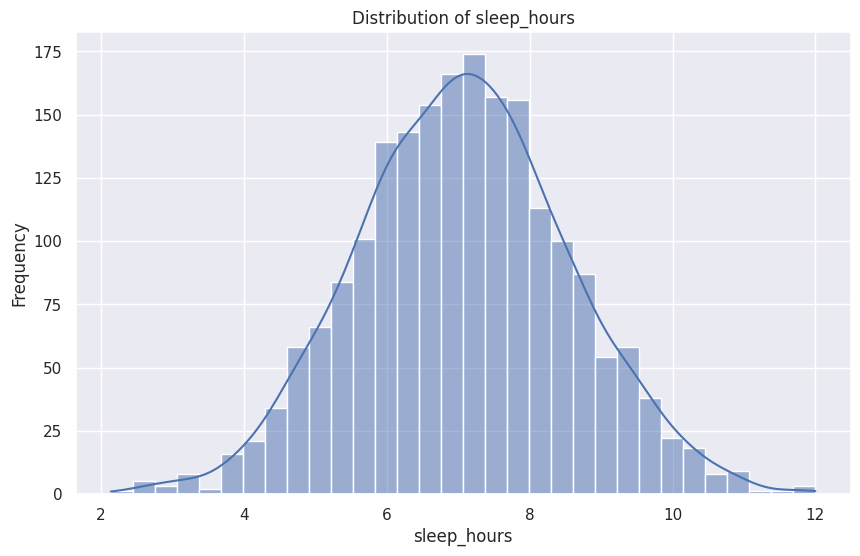

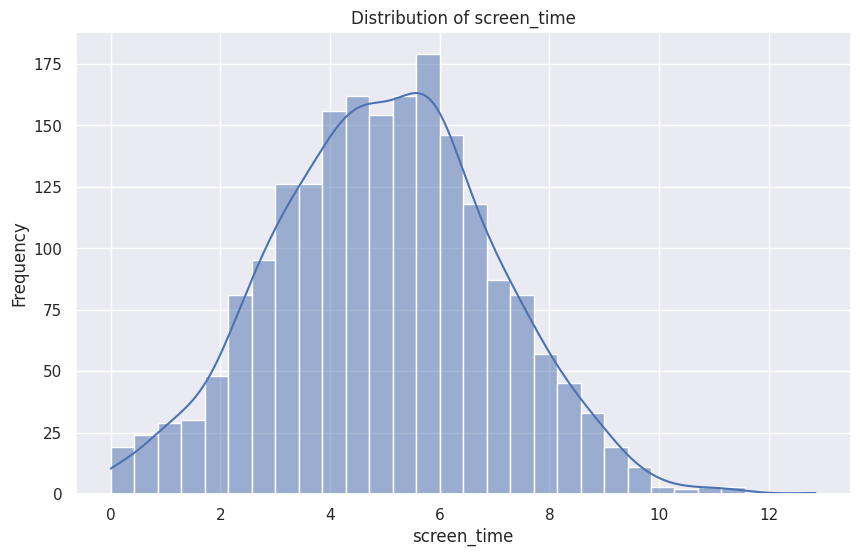

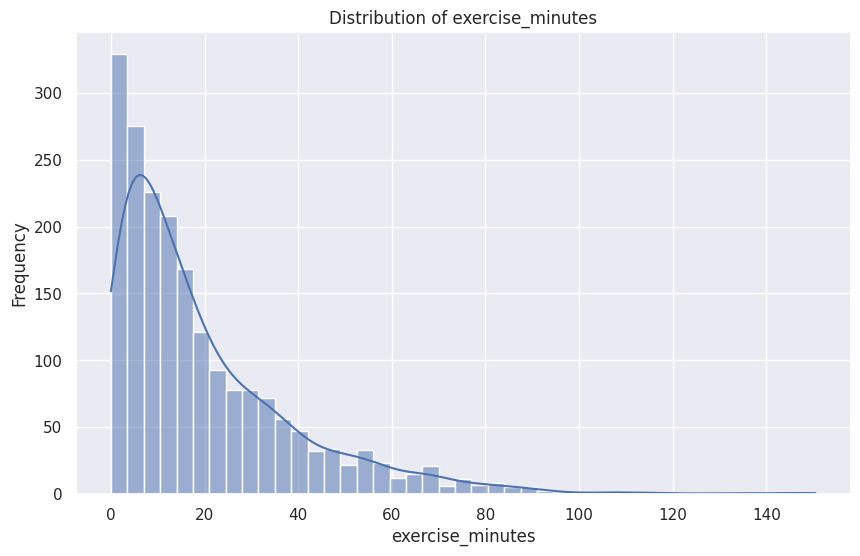

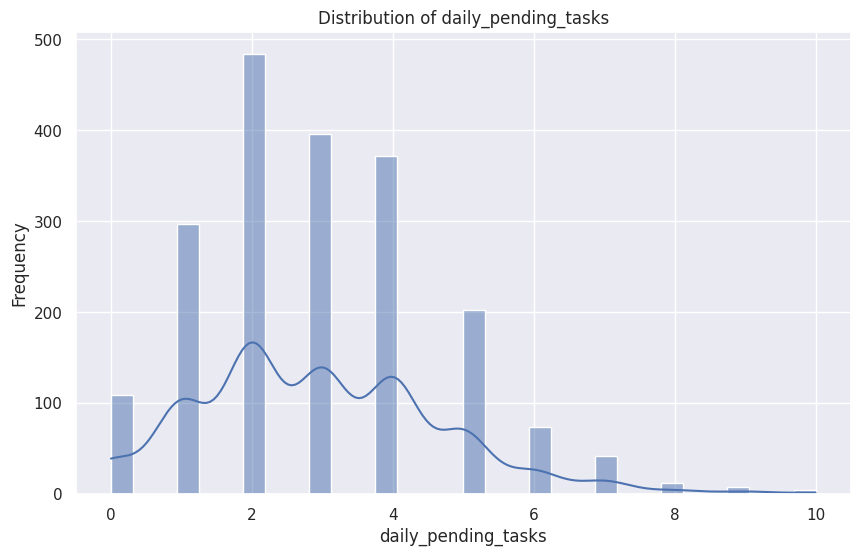

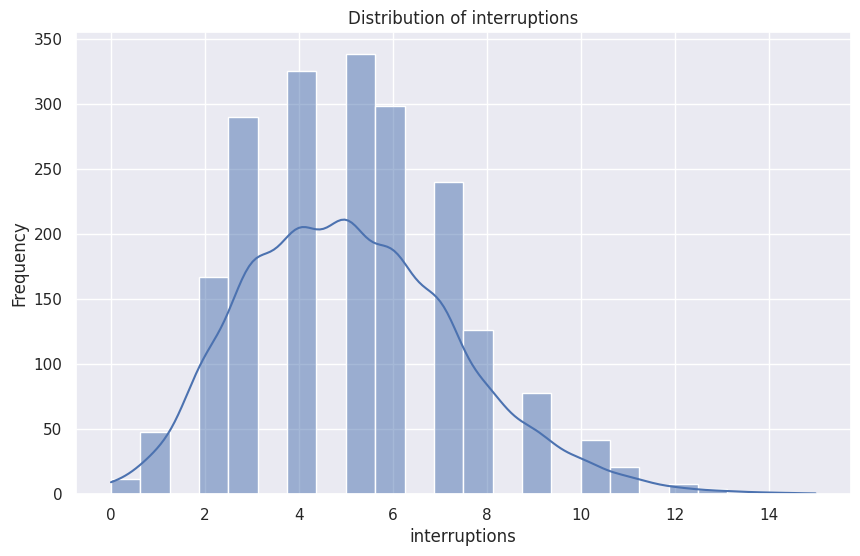

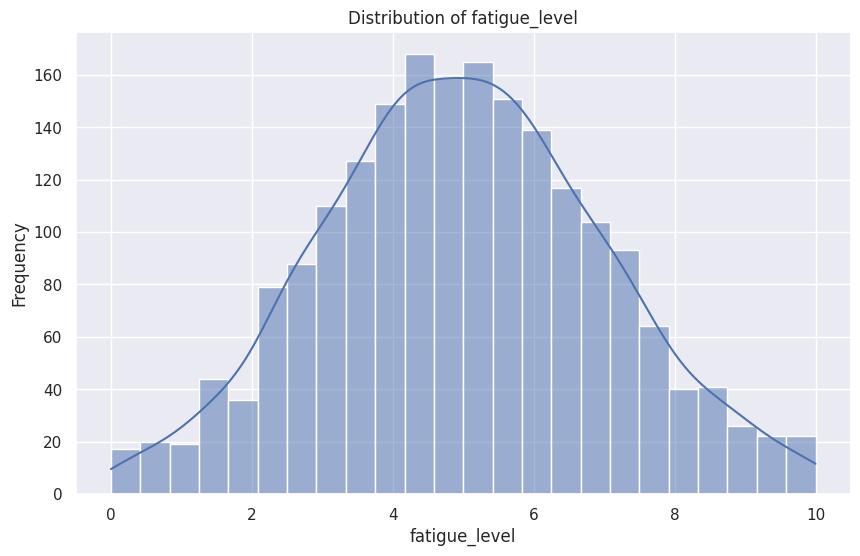

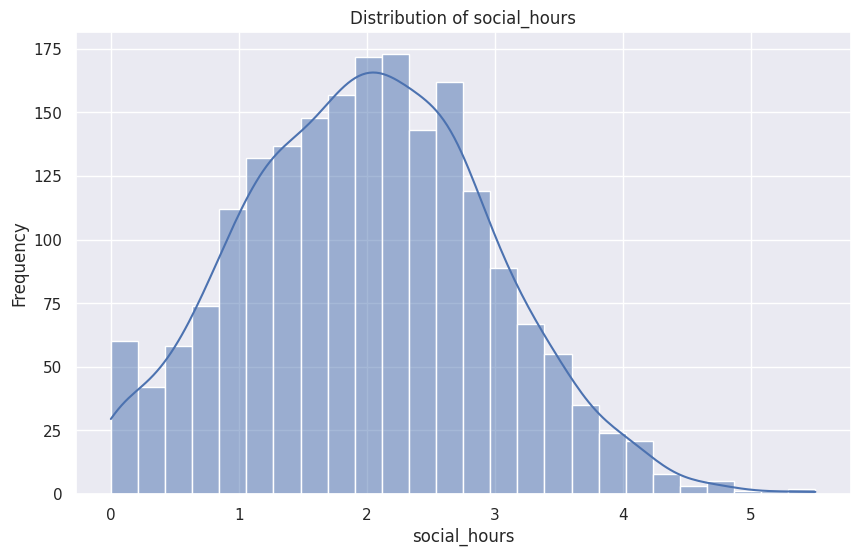

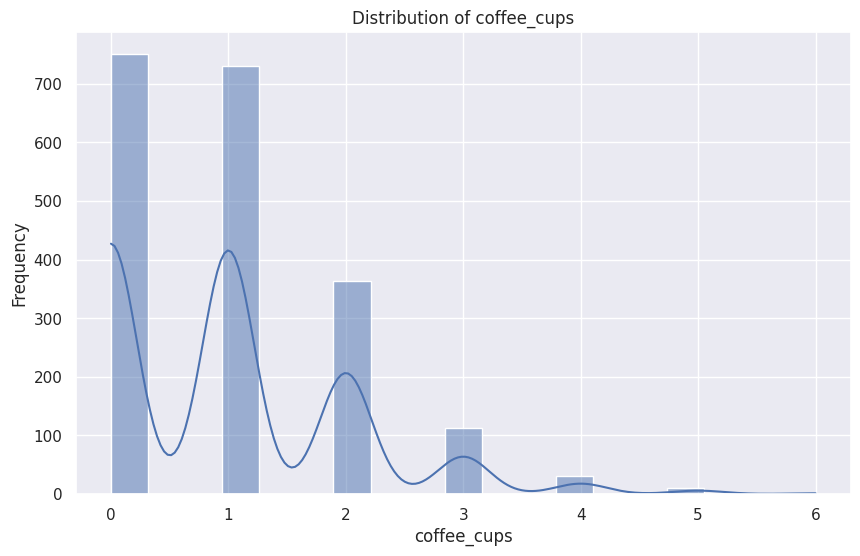

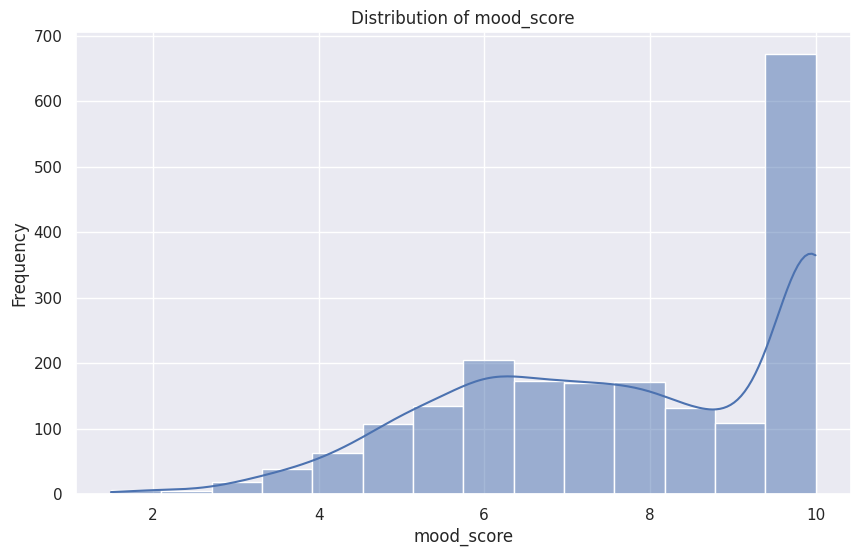

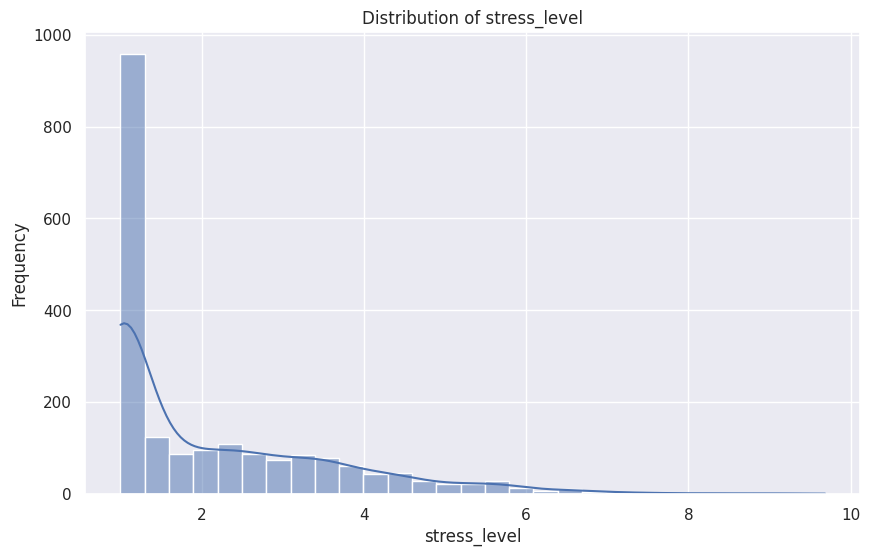

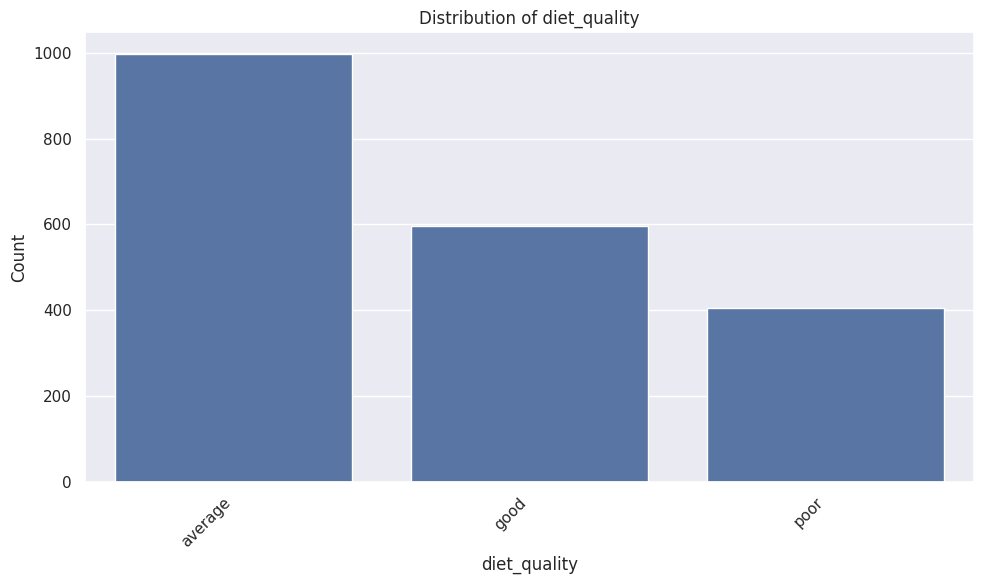

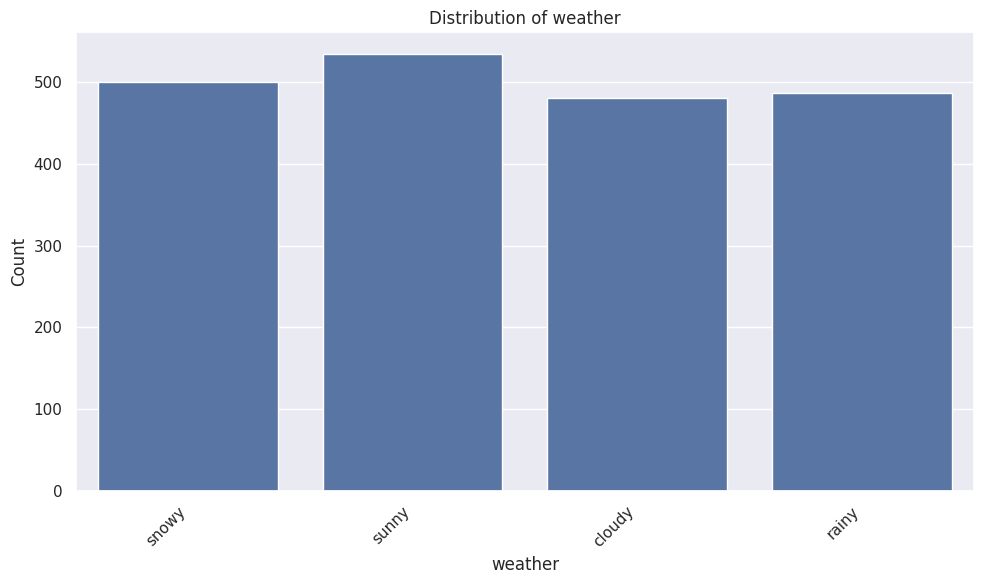

Value counts for diet_quality:
diet_quality
average    998
good       597
poor       405
Name: count, dtype: int64

Value counts for weather:
weather
sunny     534
snowy     500
rainy     486
cloudy    480
Name: count, dtype: int64



In [16]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

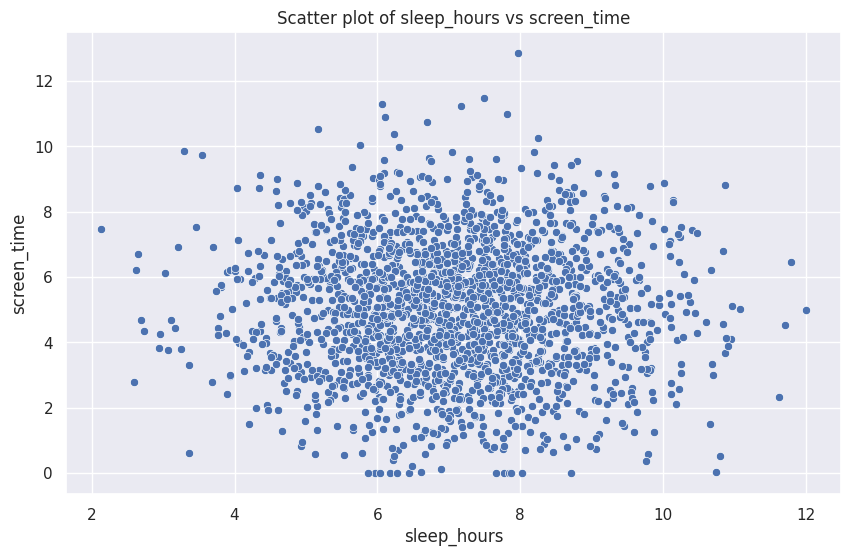

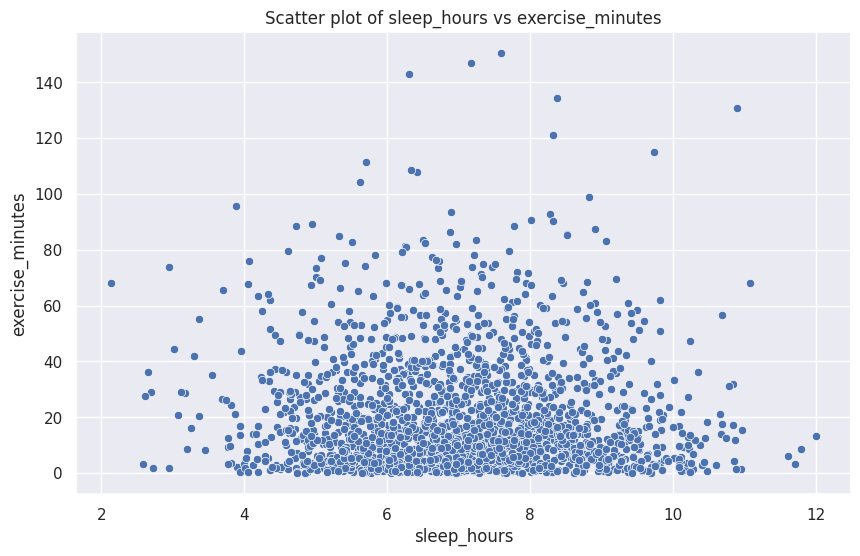

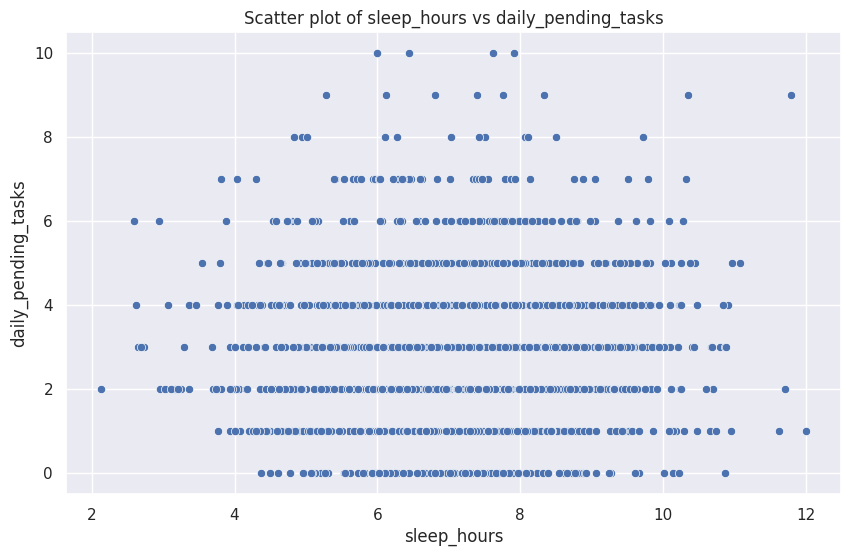

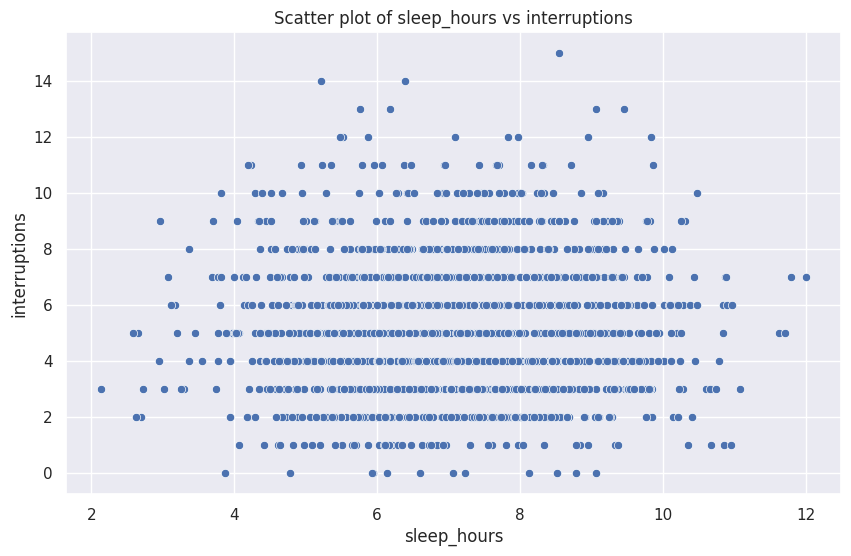

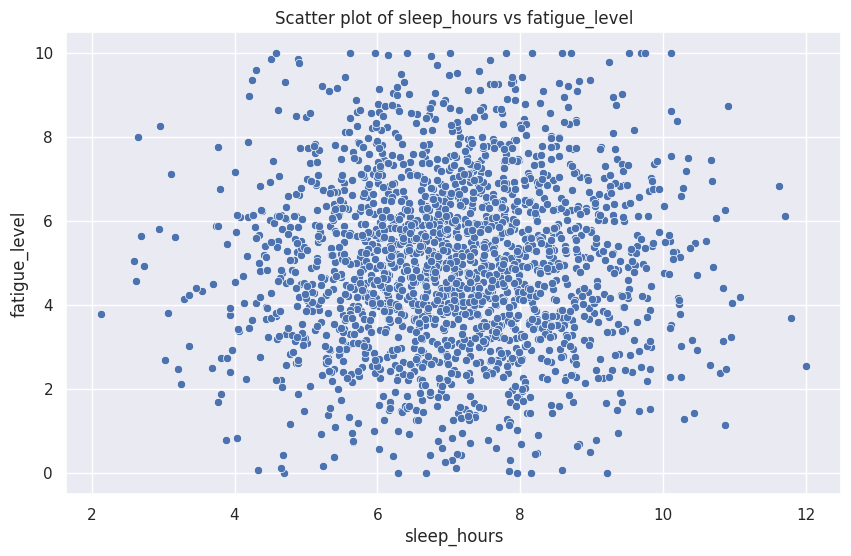

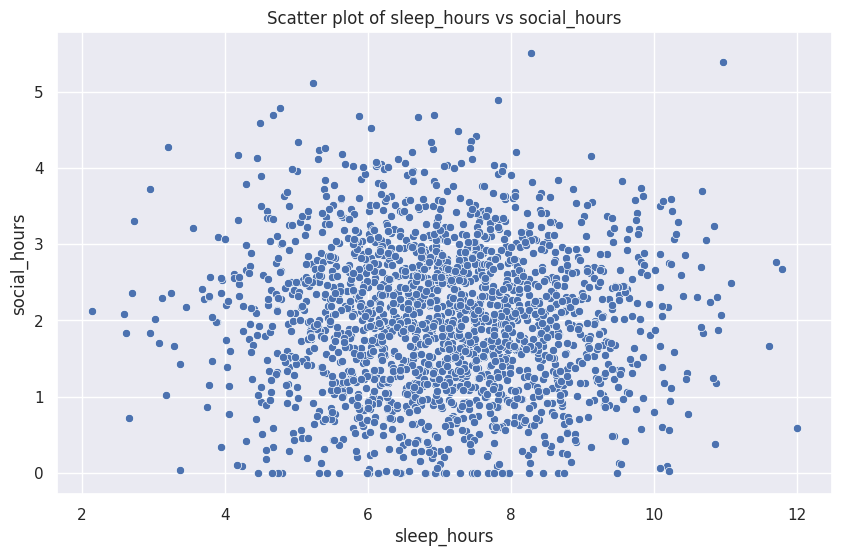

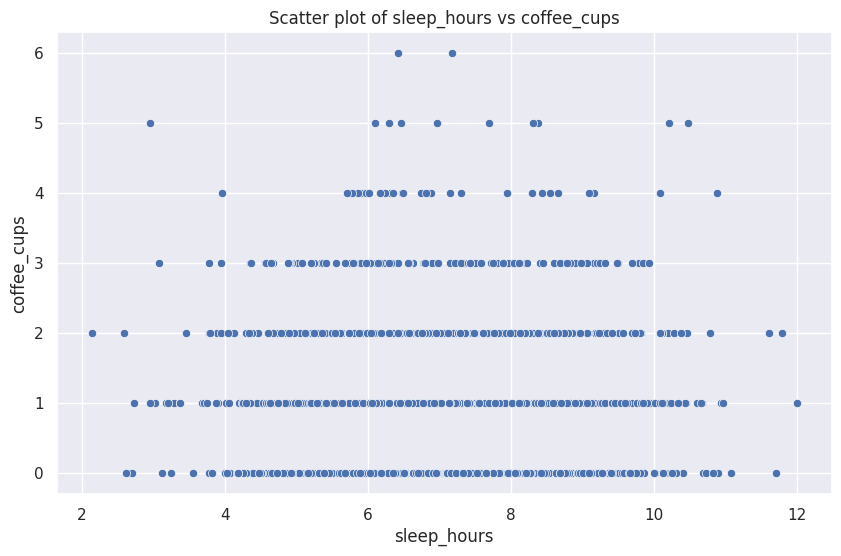

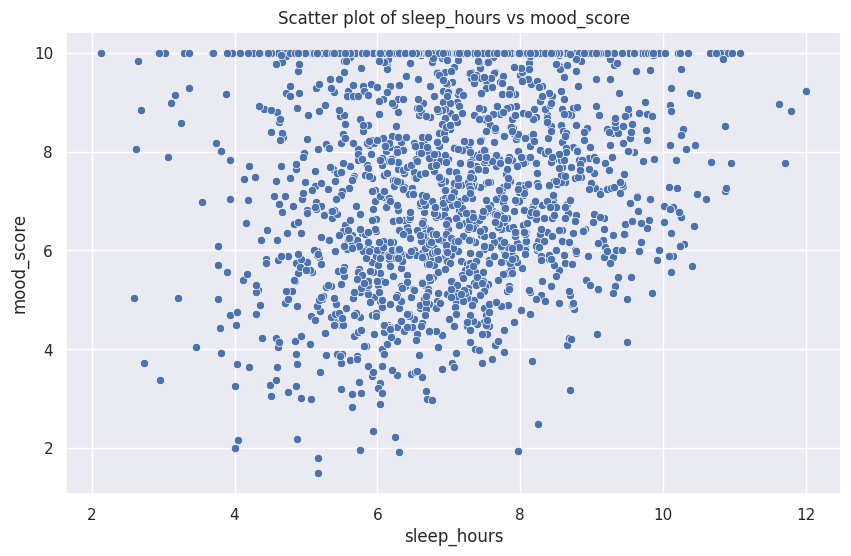

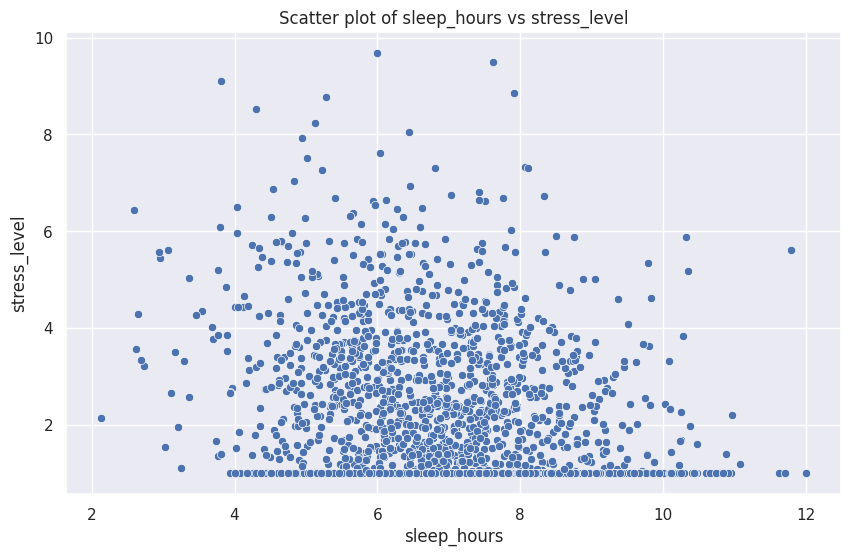

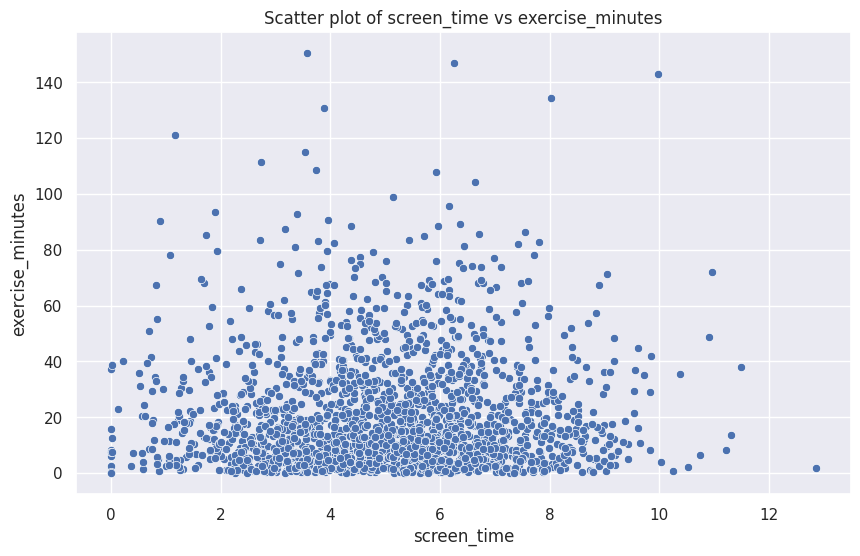

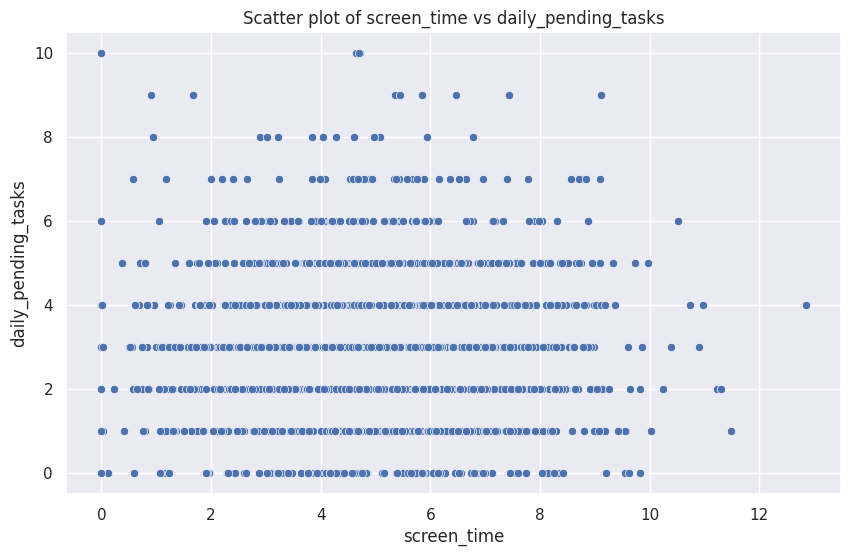

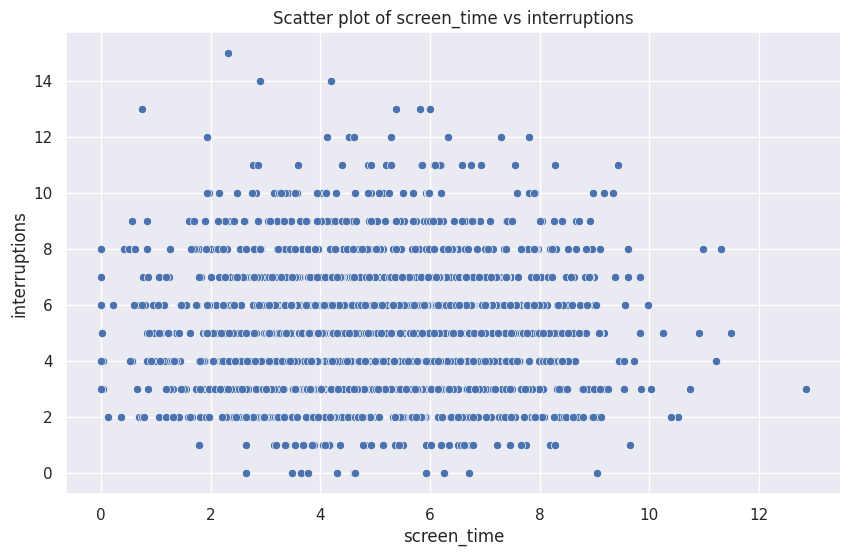

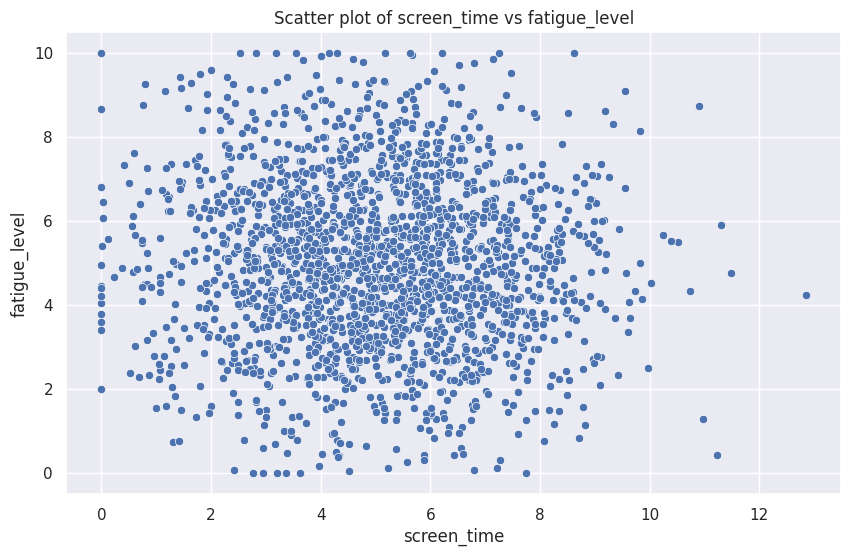

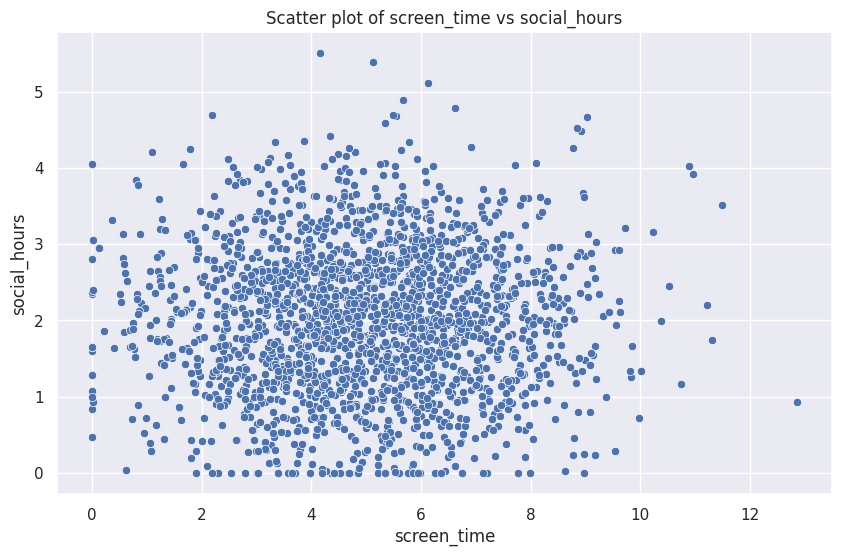

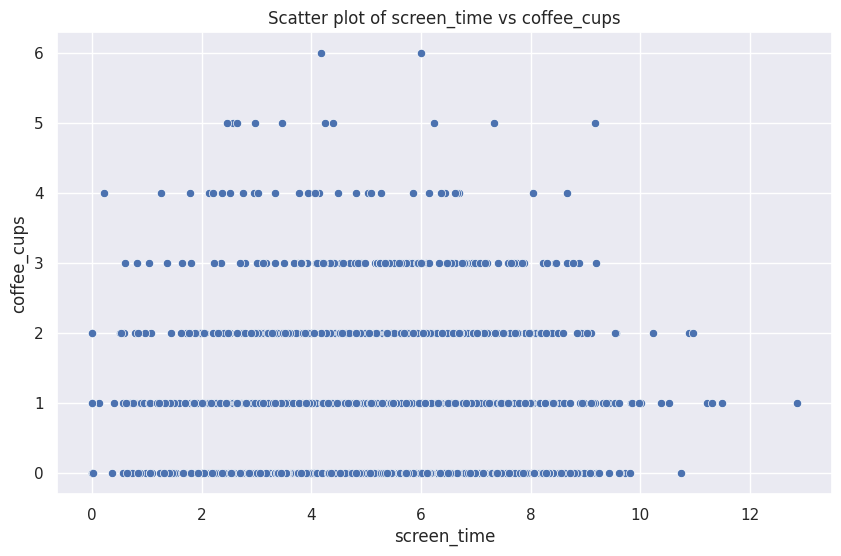

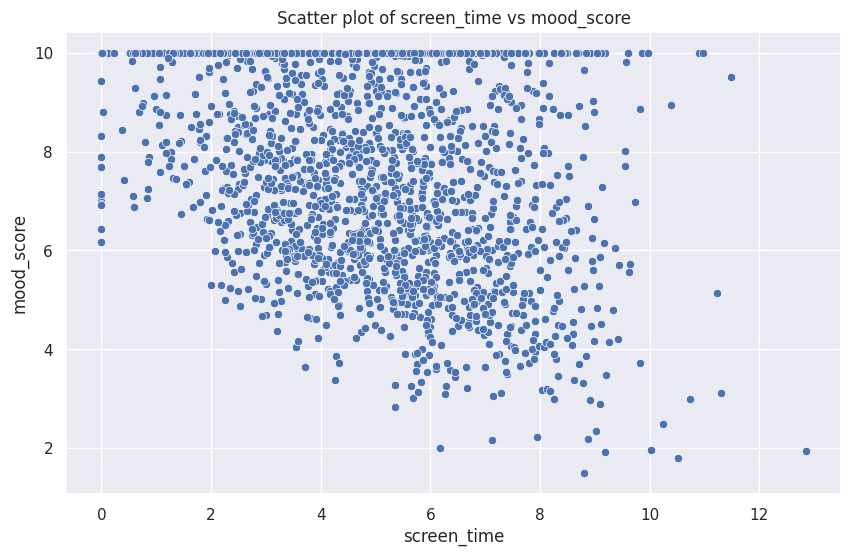

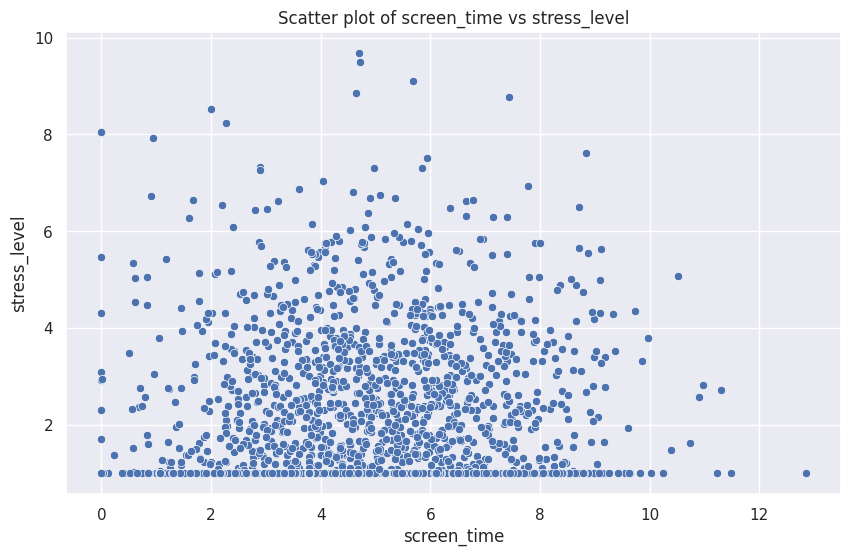

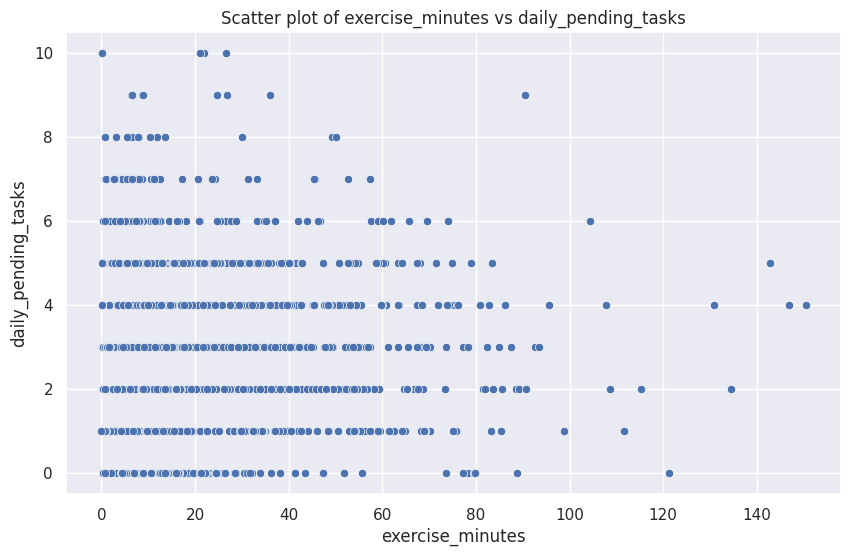

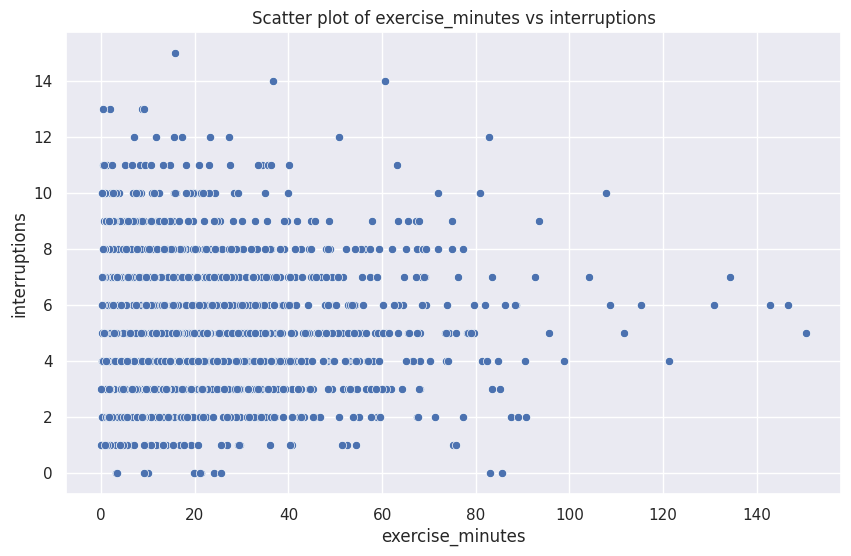

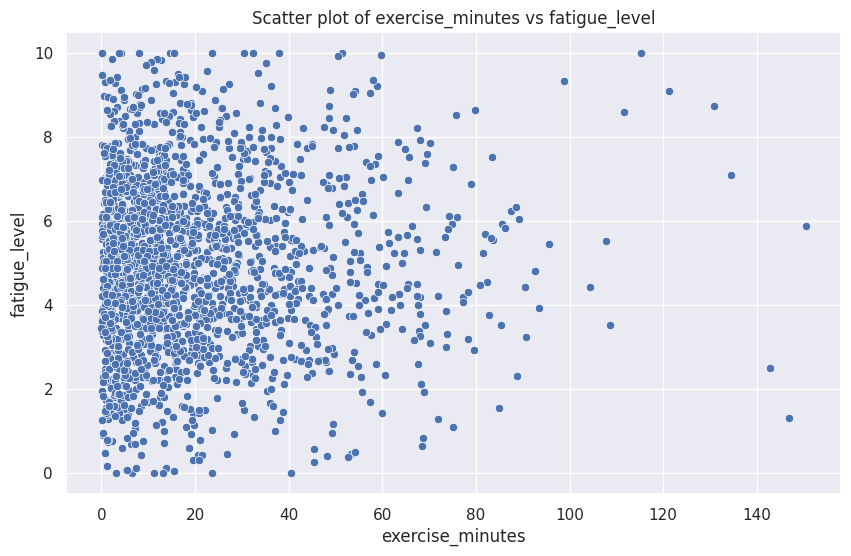

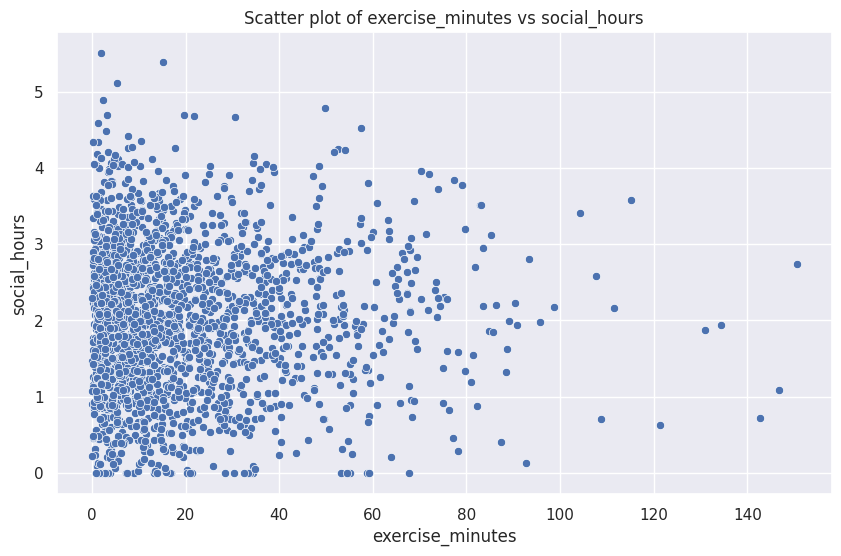

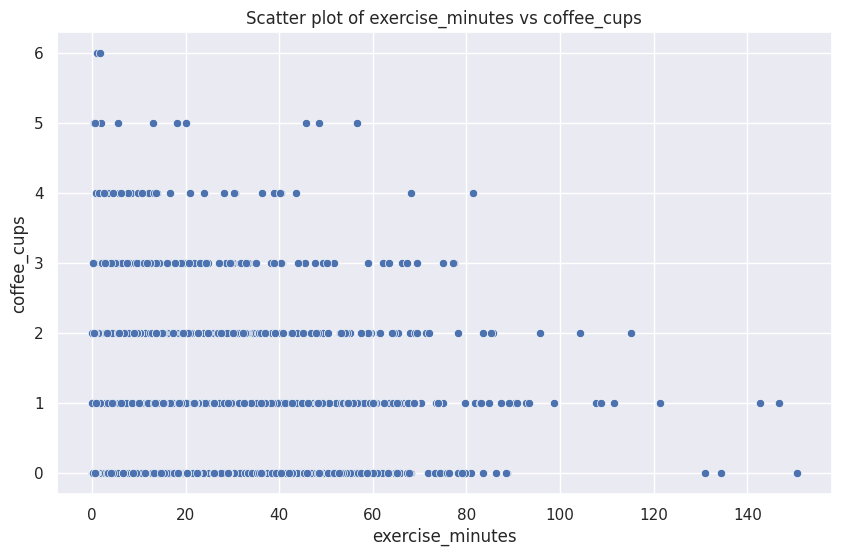

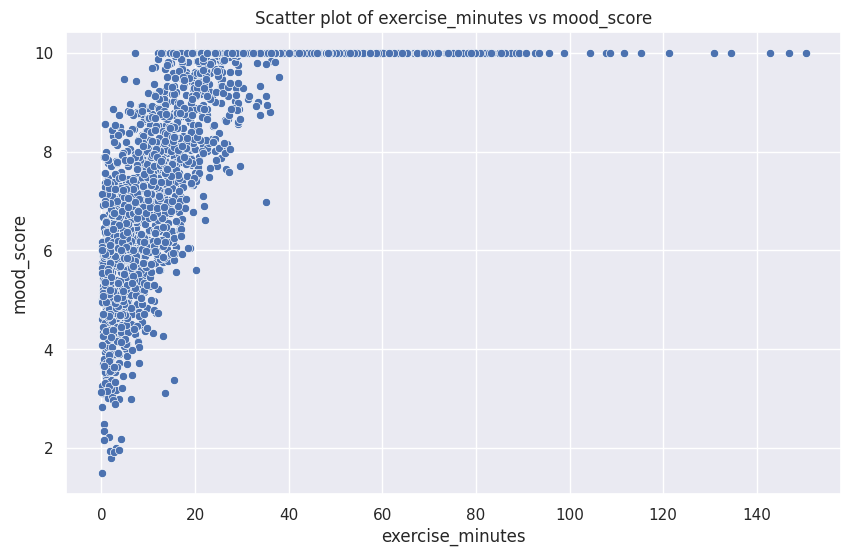

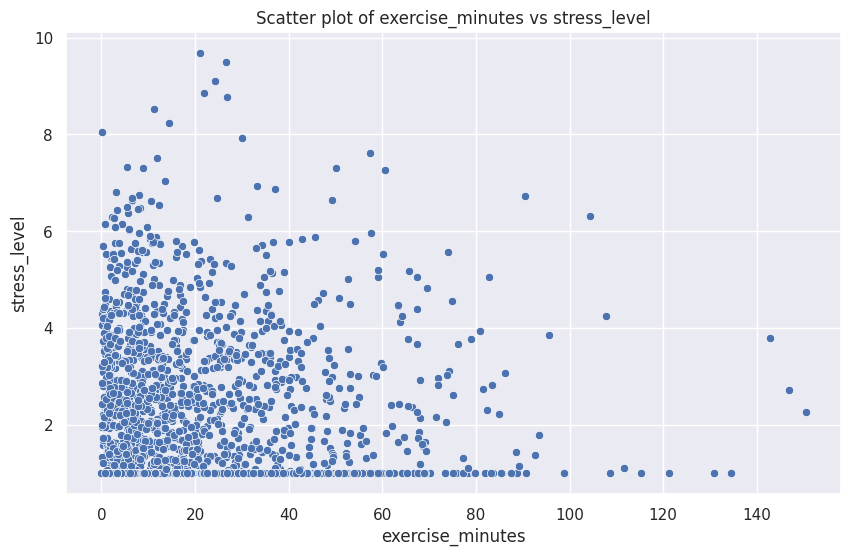

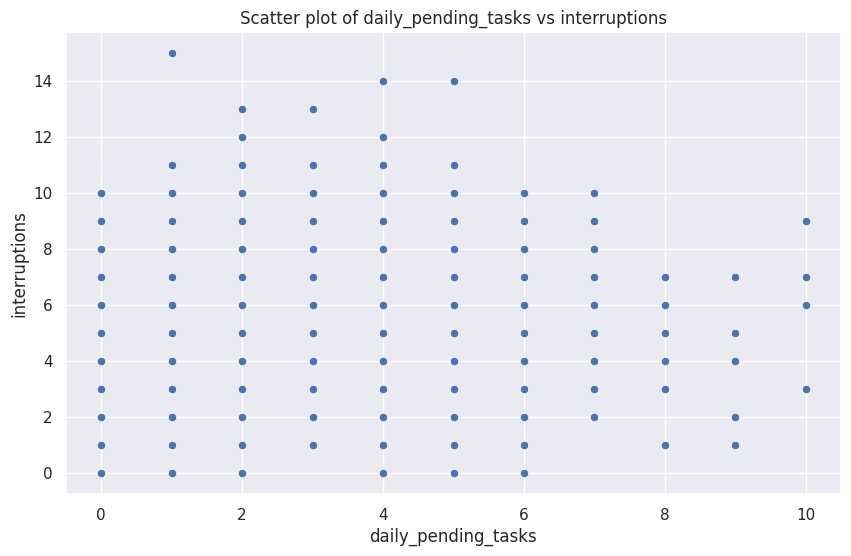

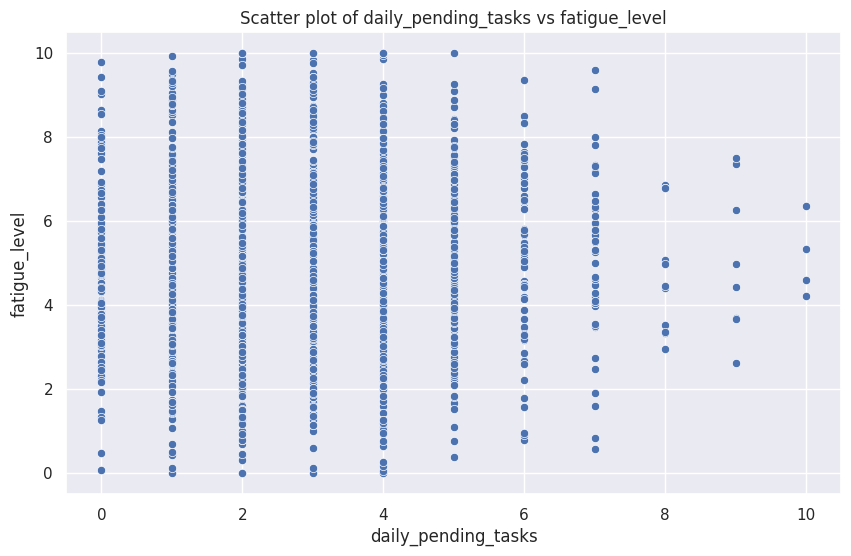

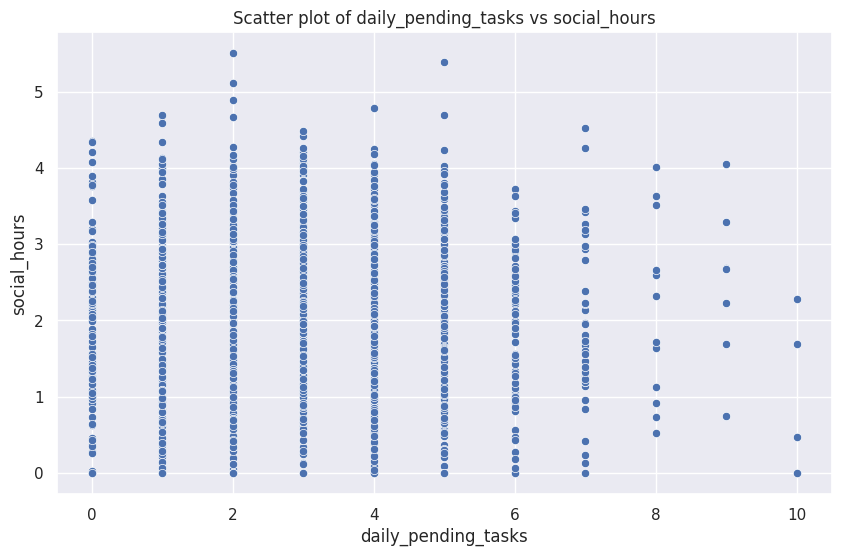

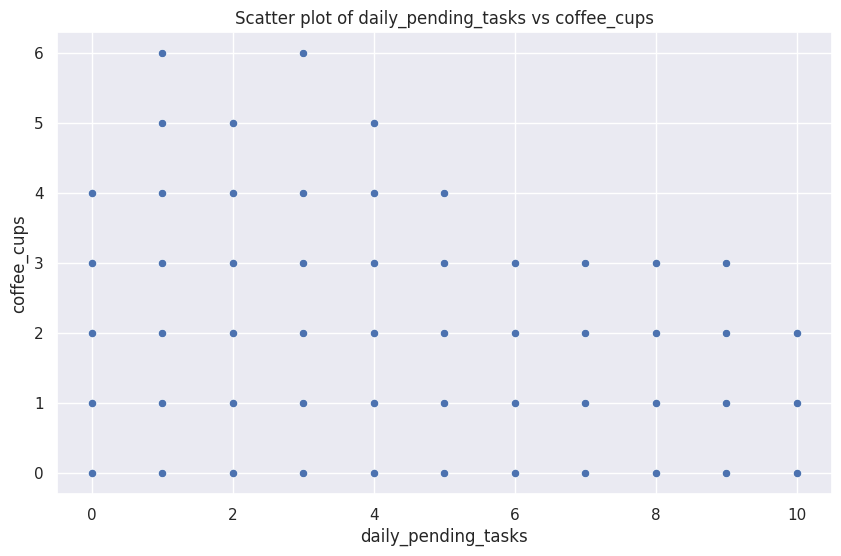

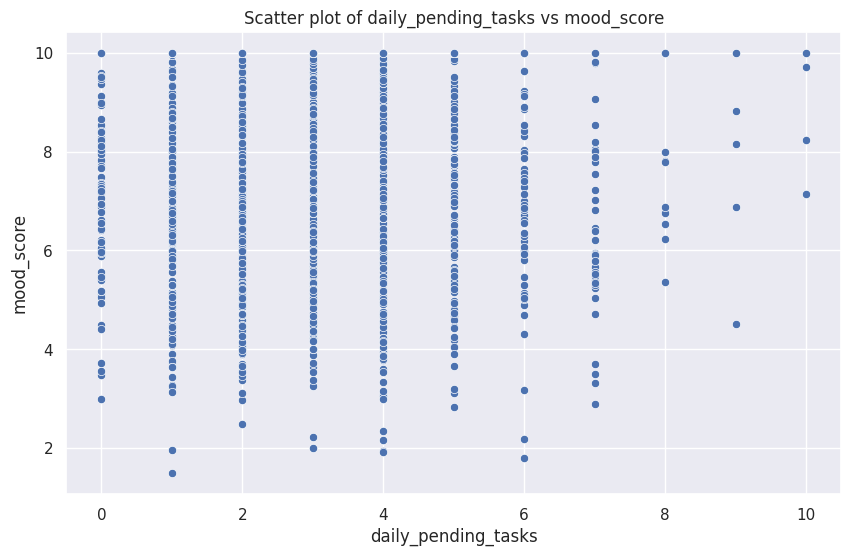

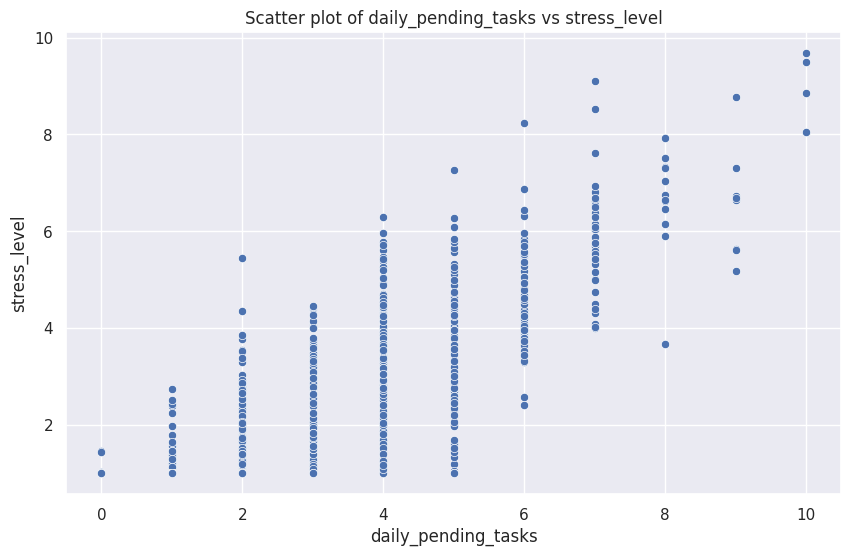

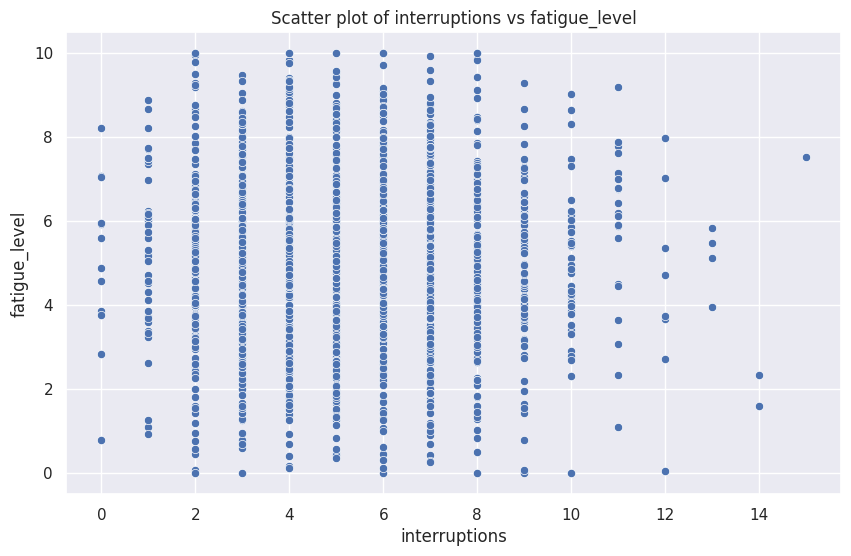

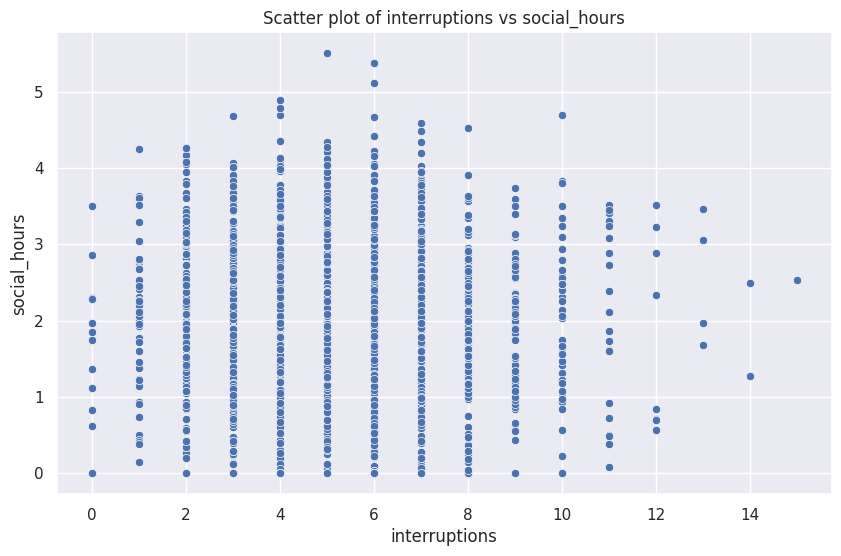

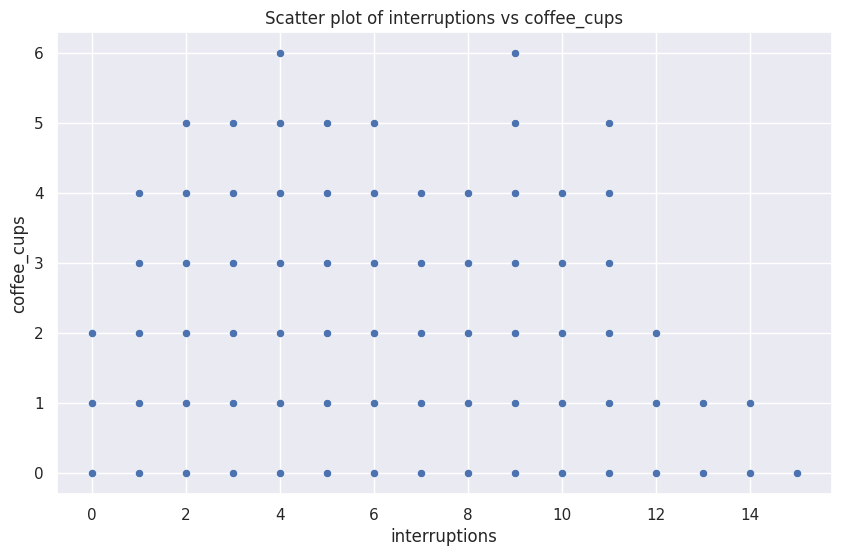

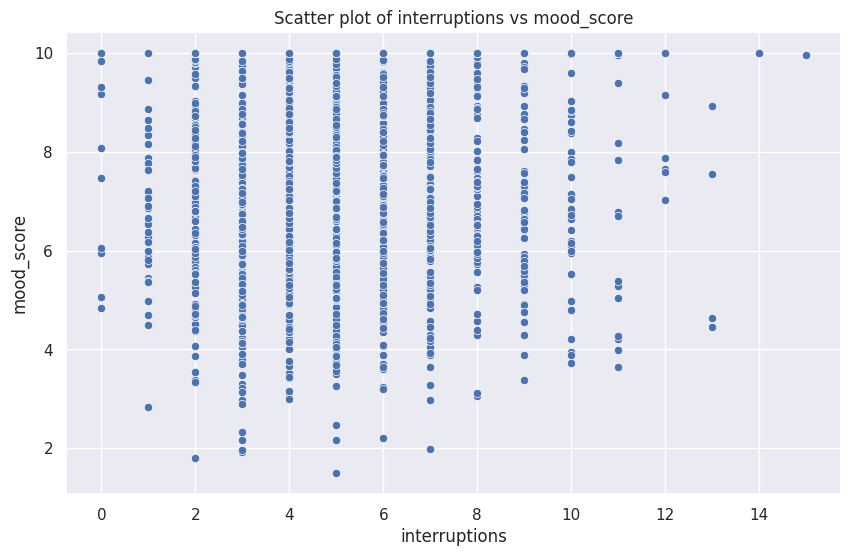

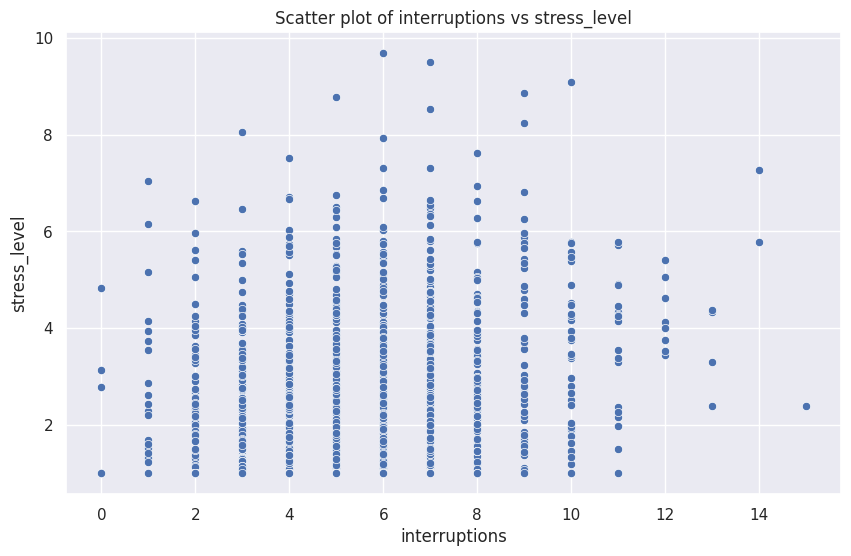

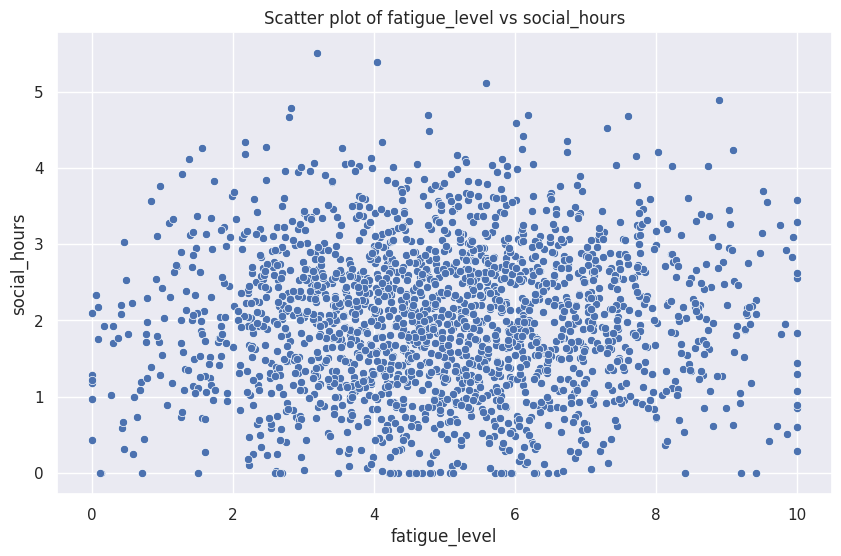

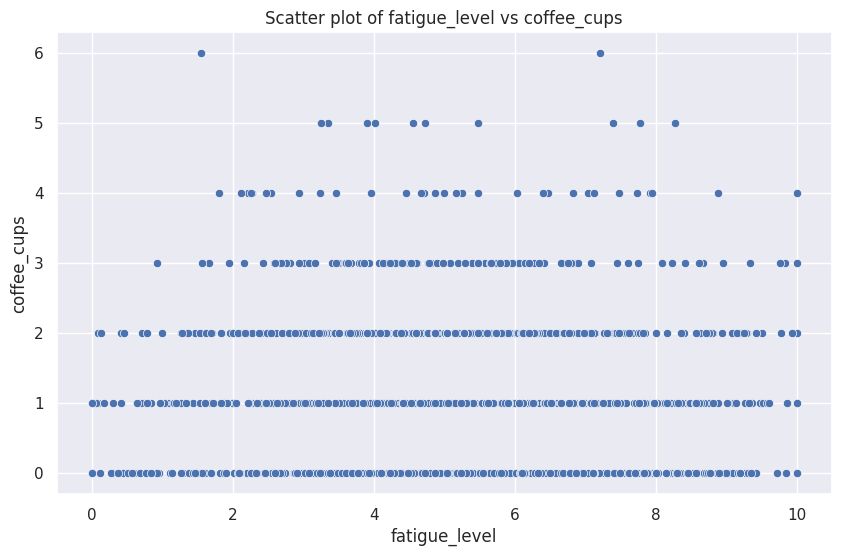

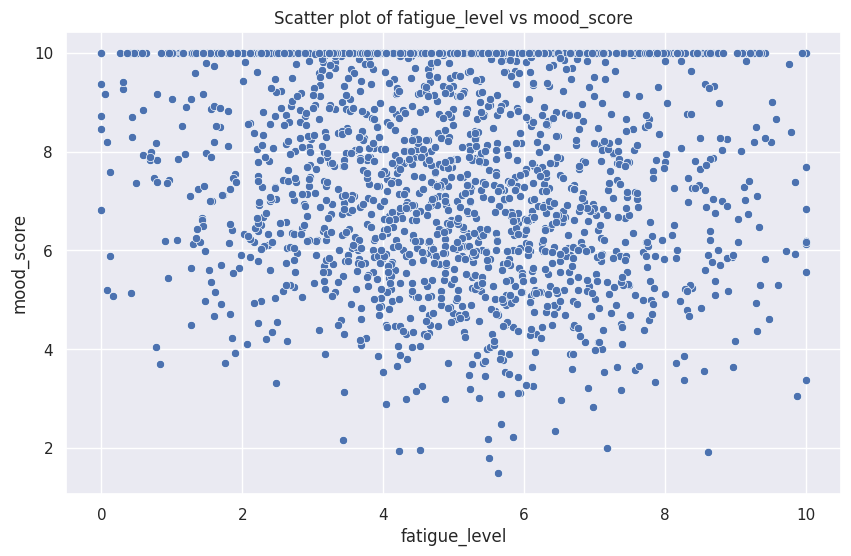

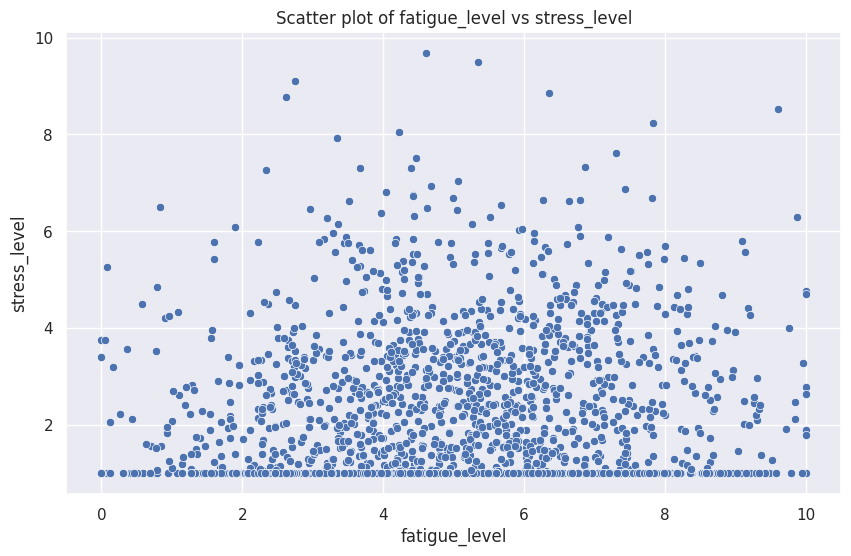

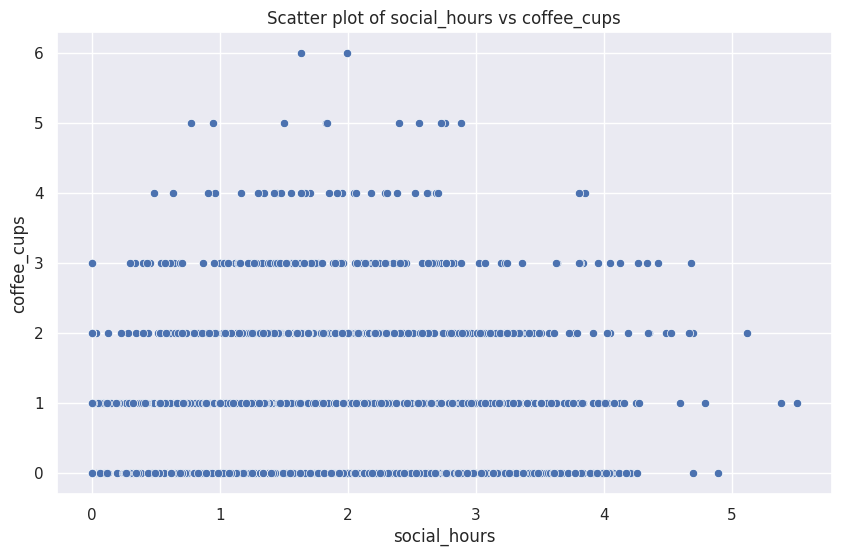

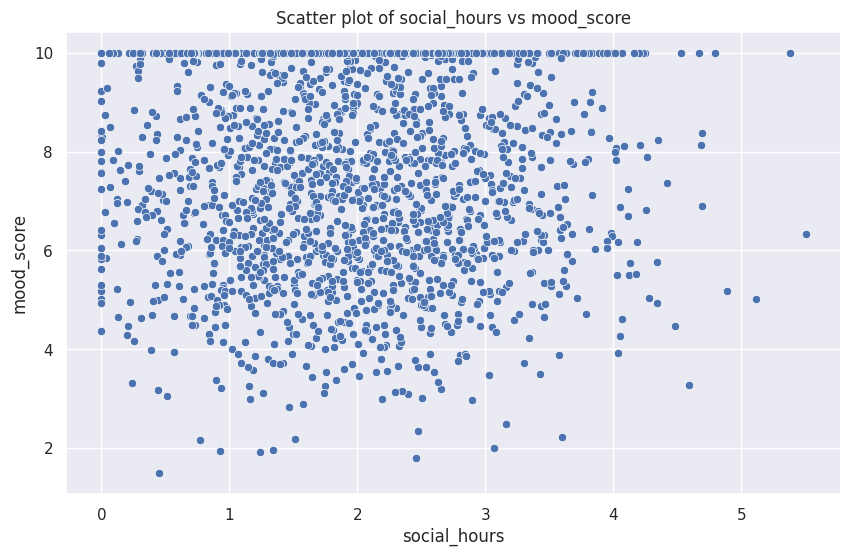

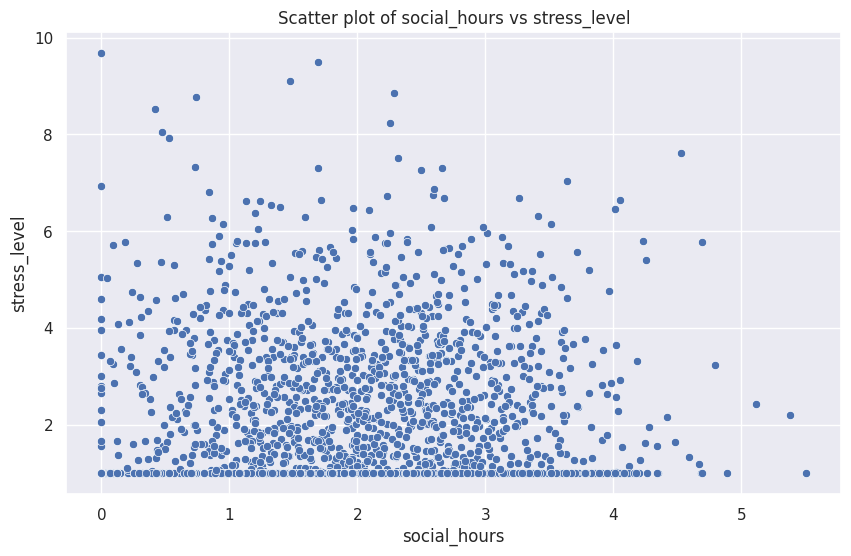

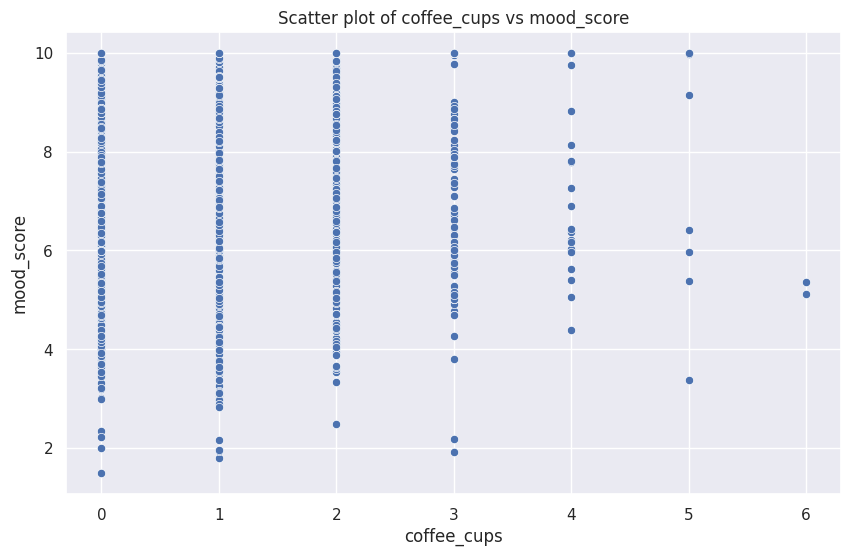

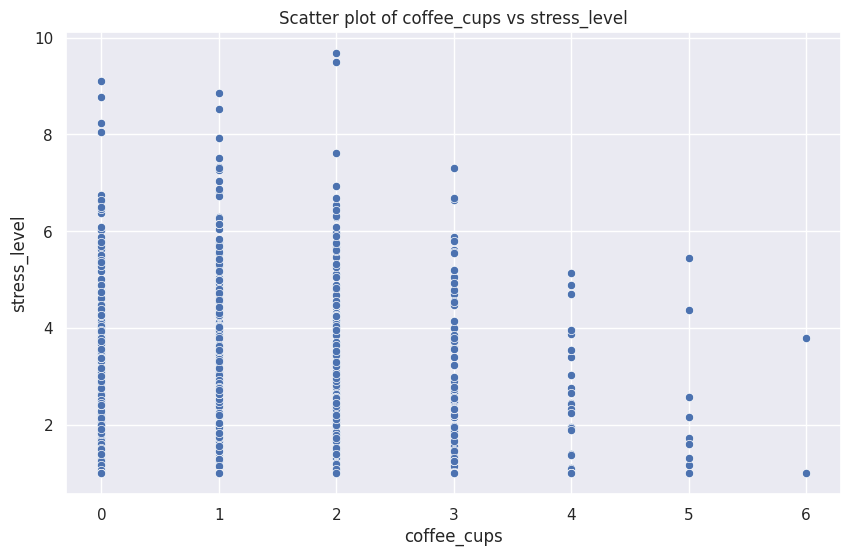

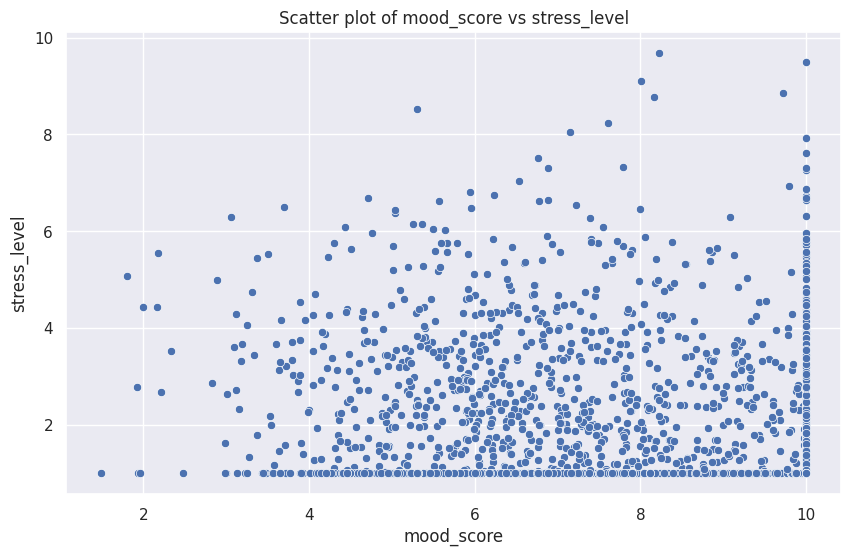

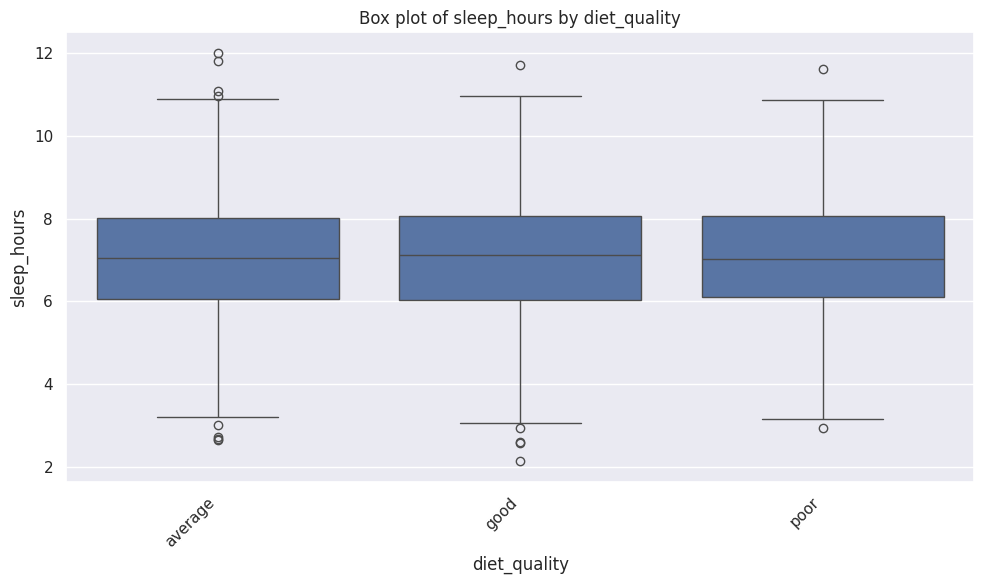

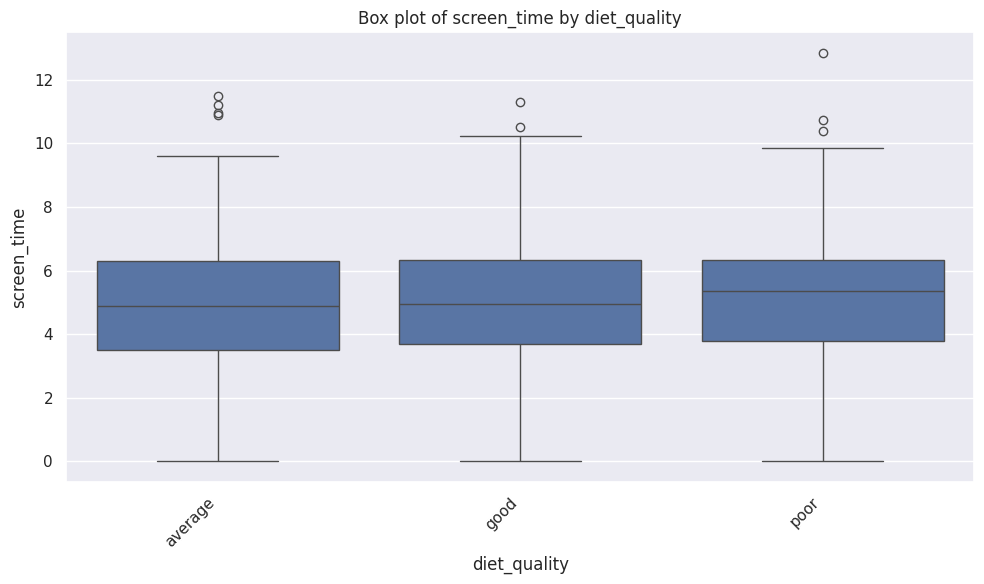

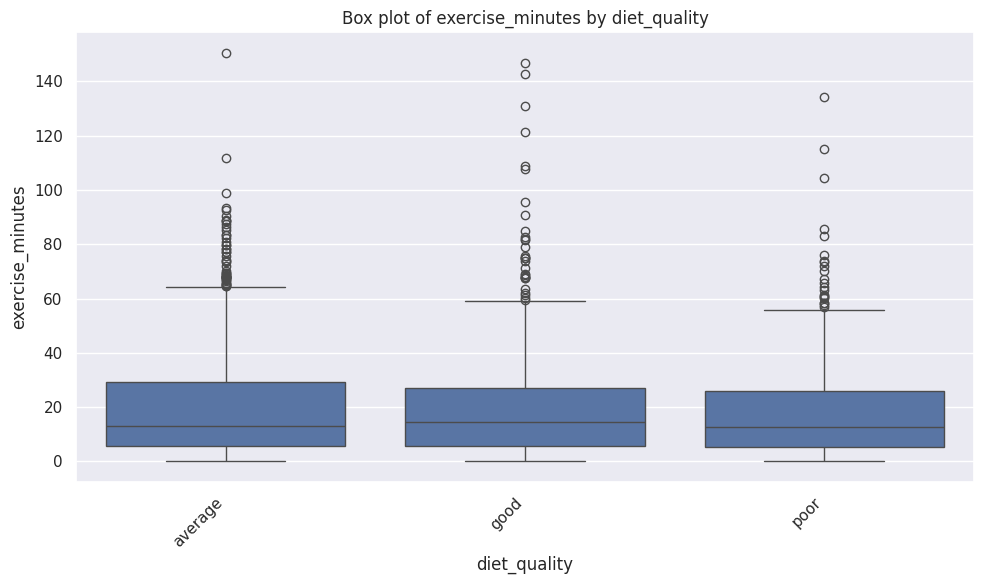

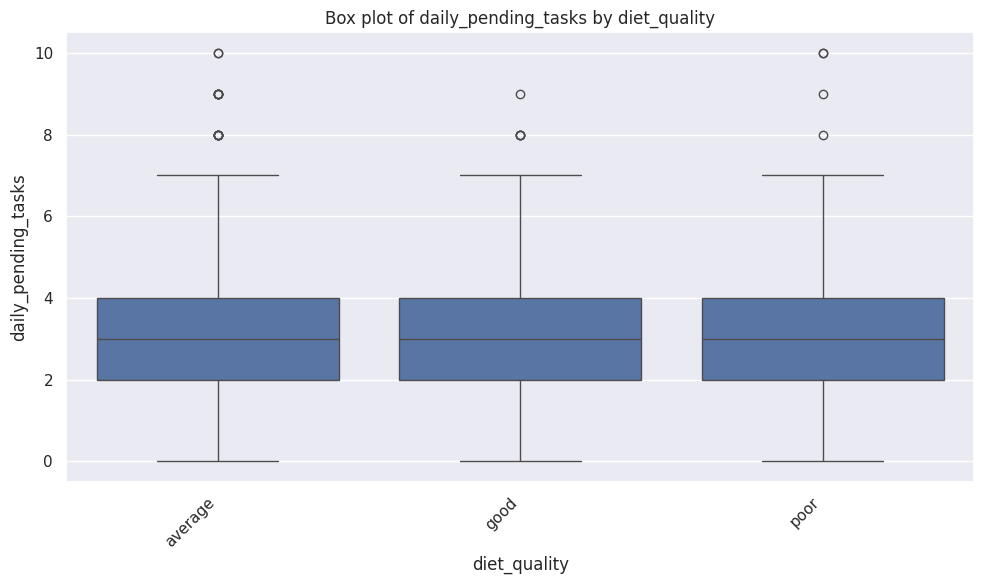

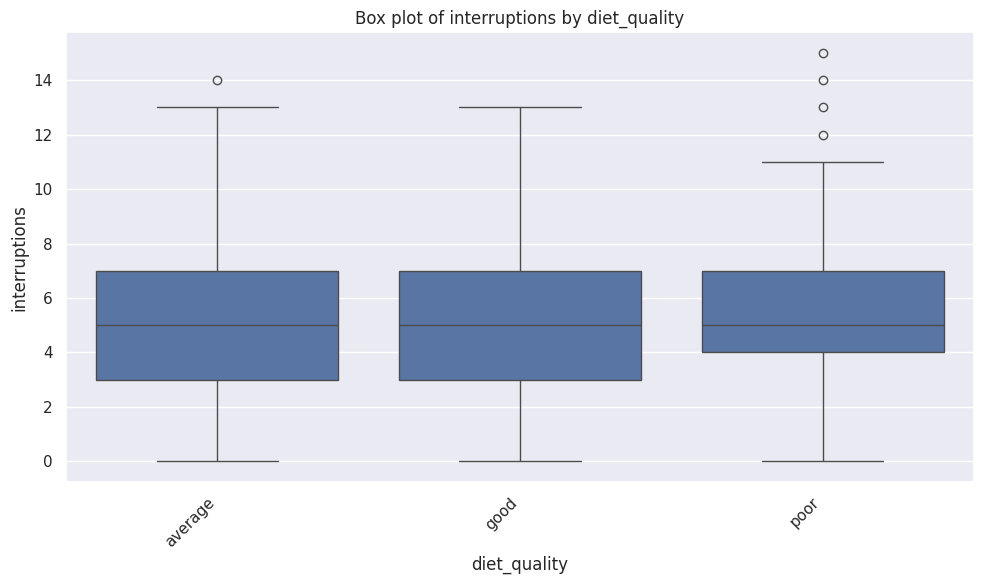

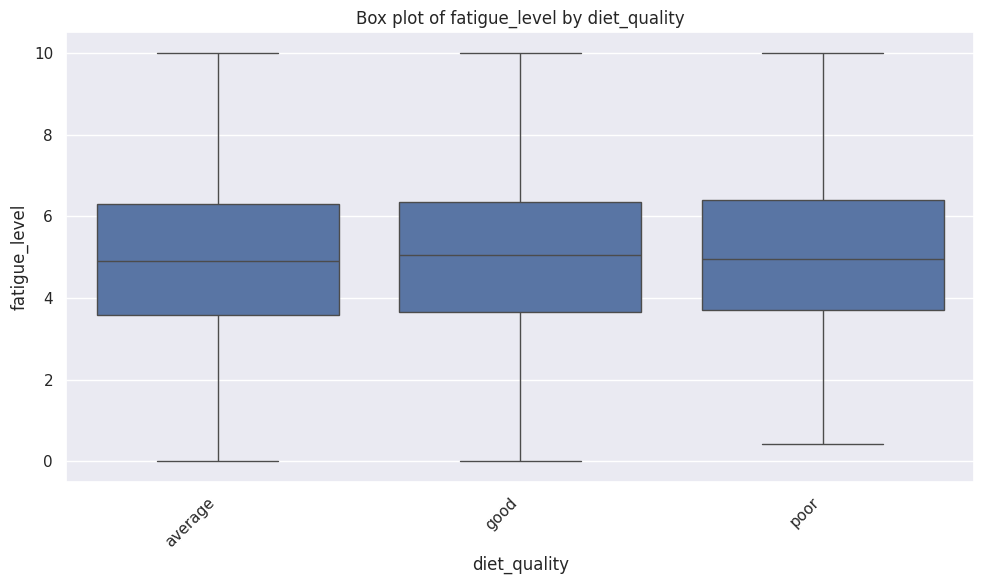

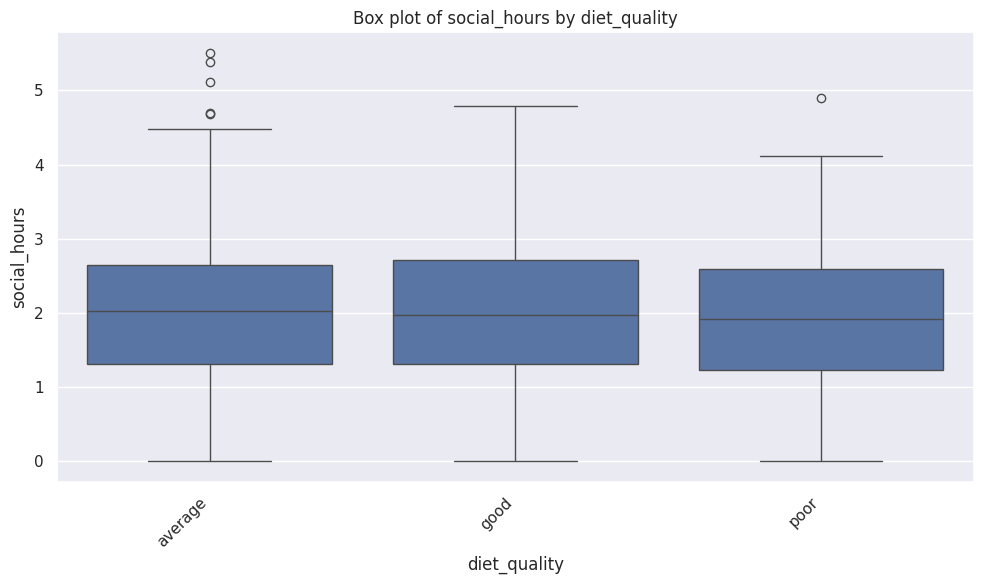

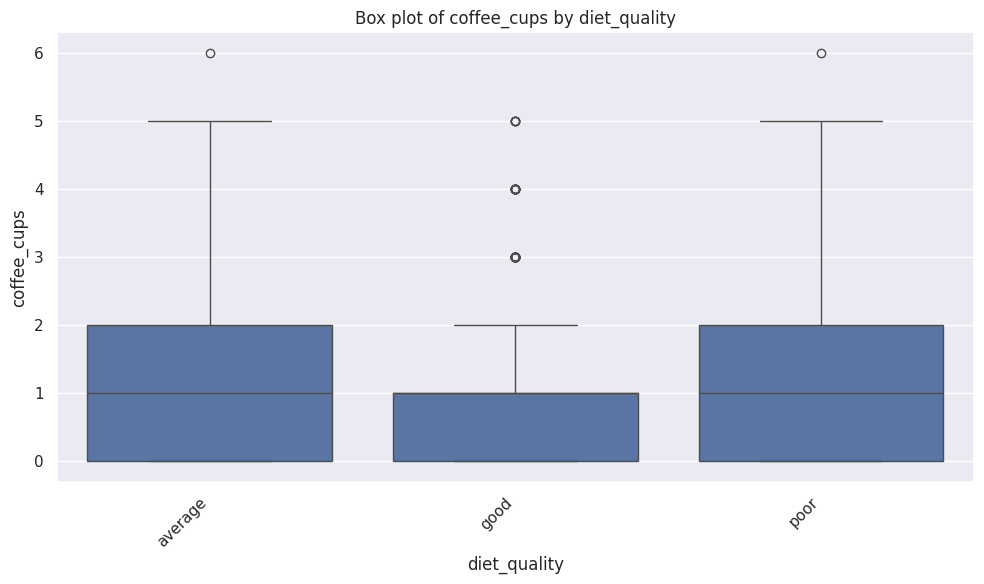

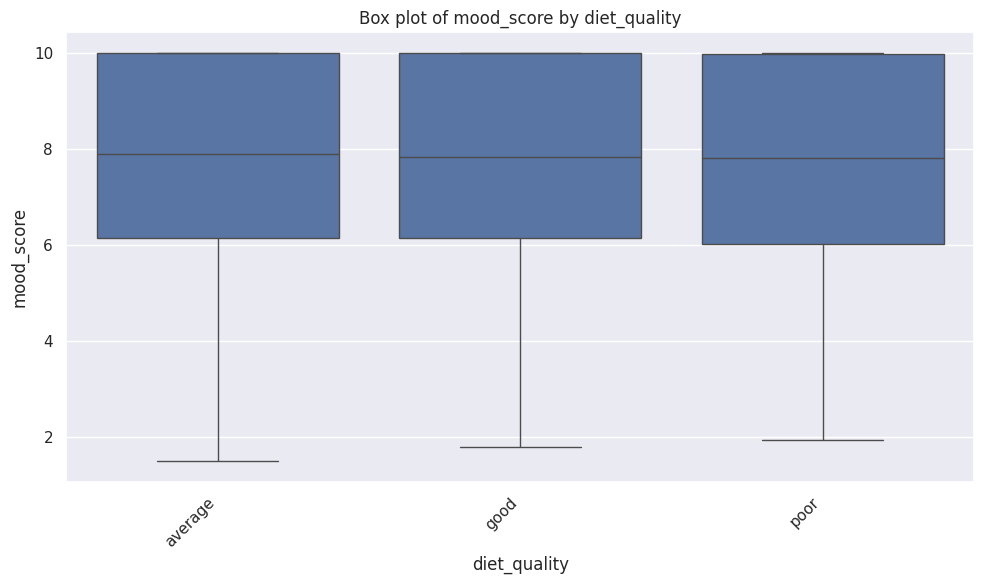

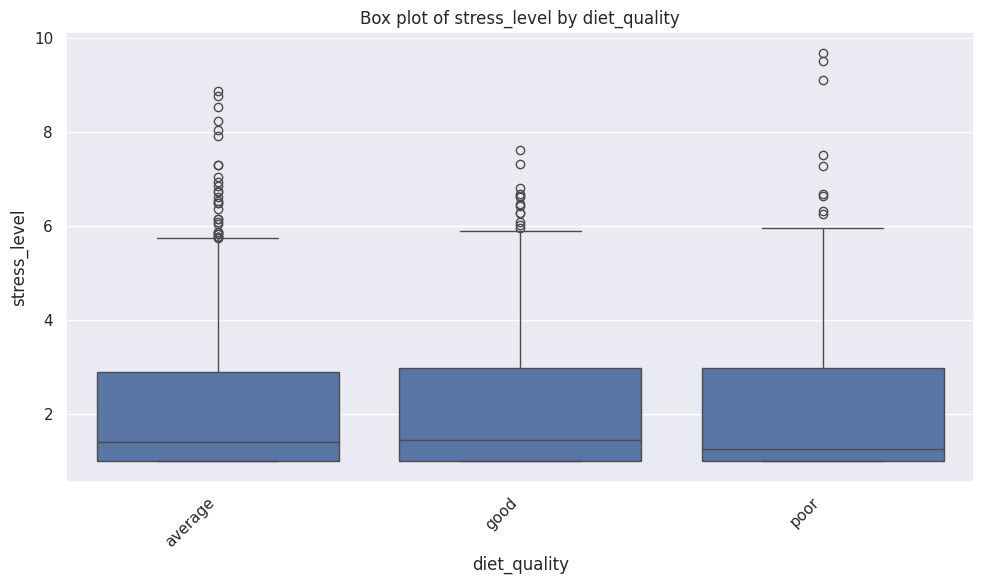

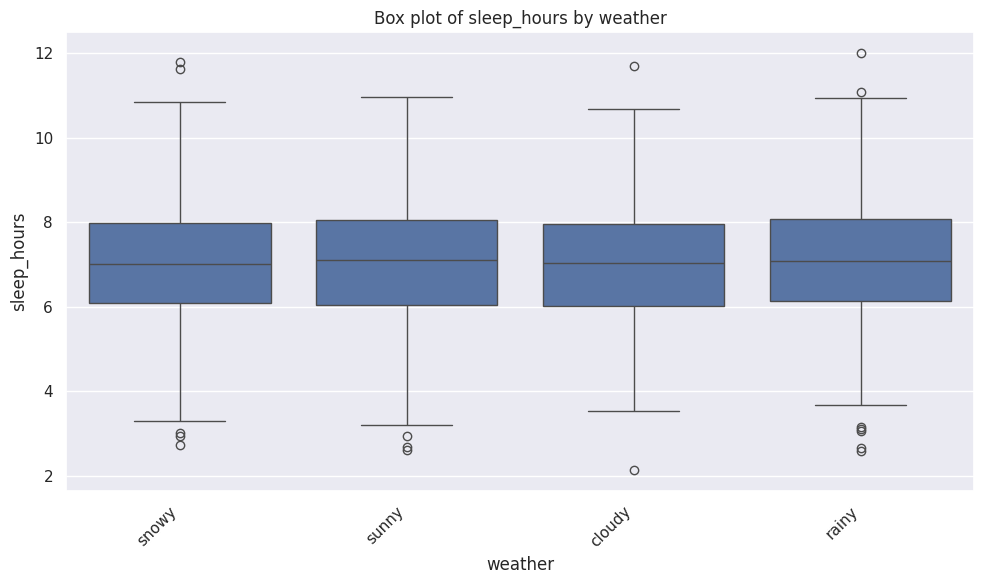

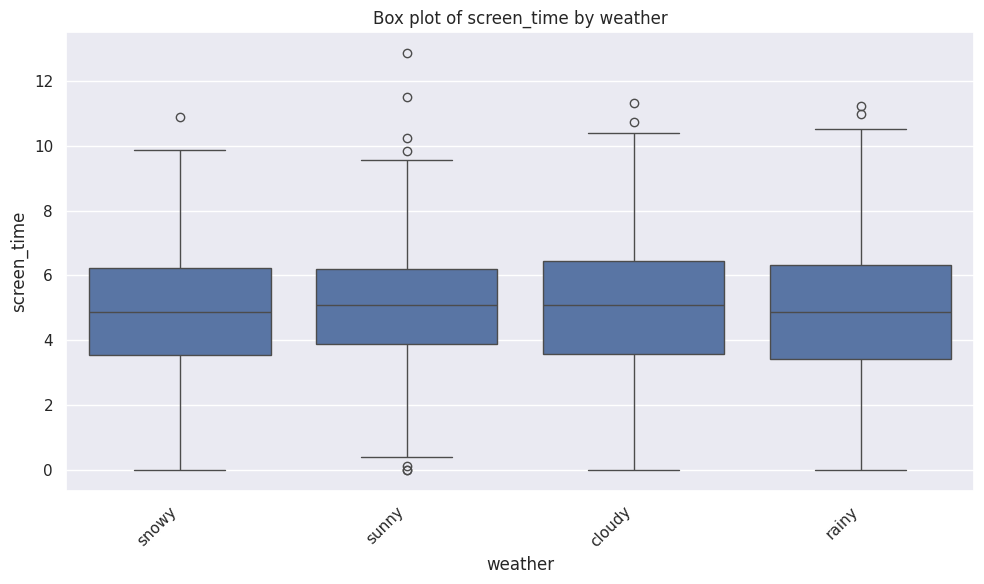

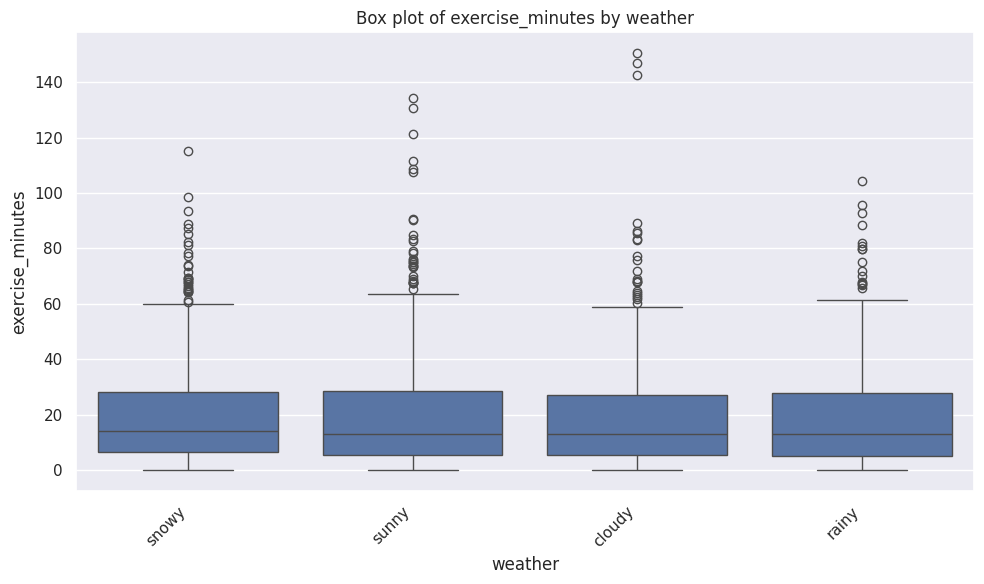

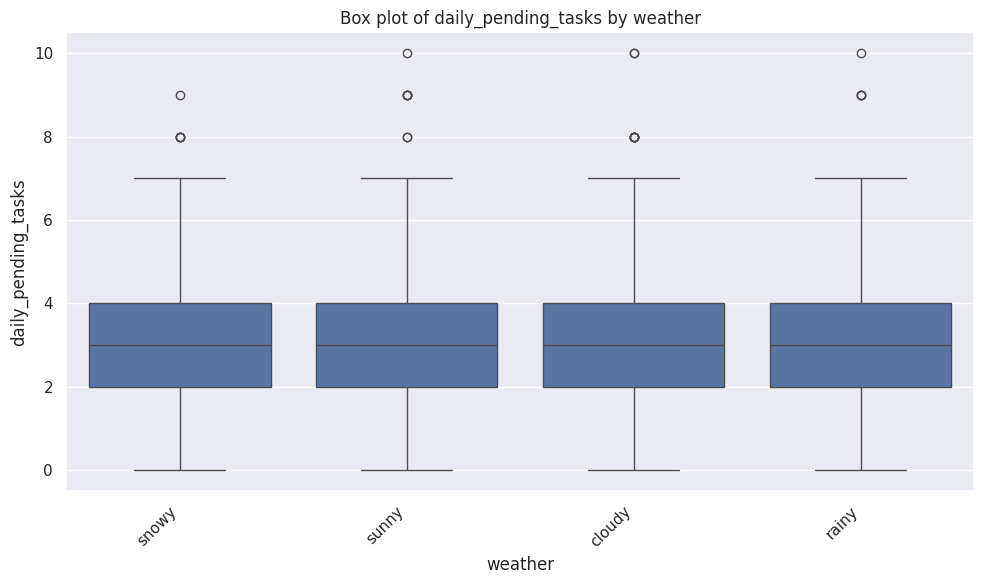

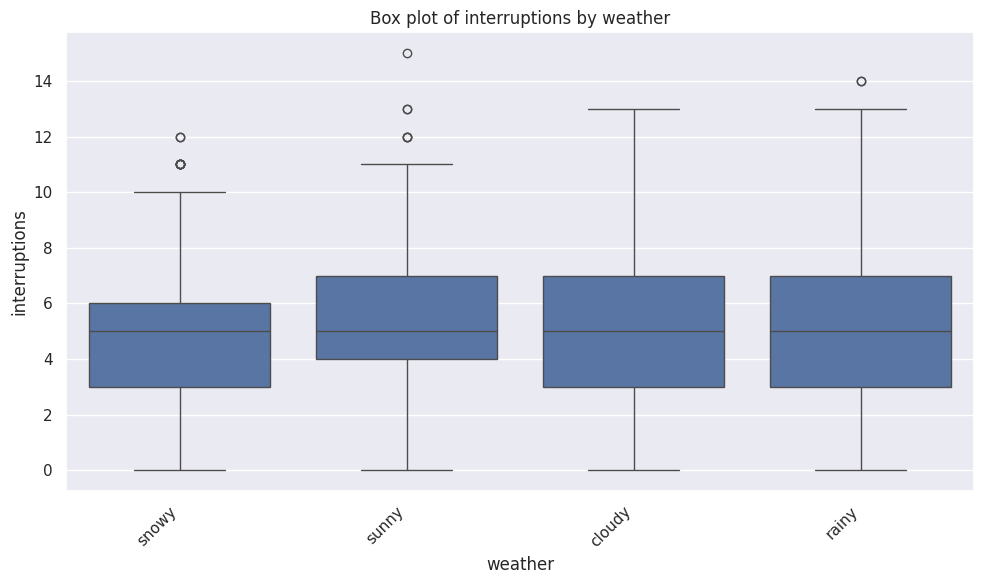

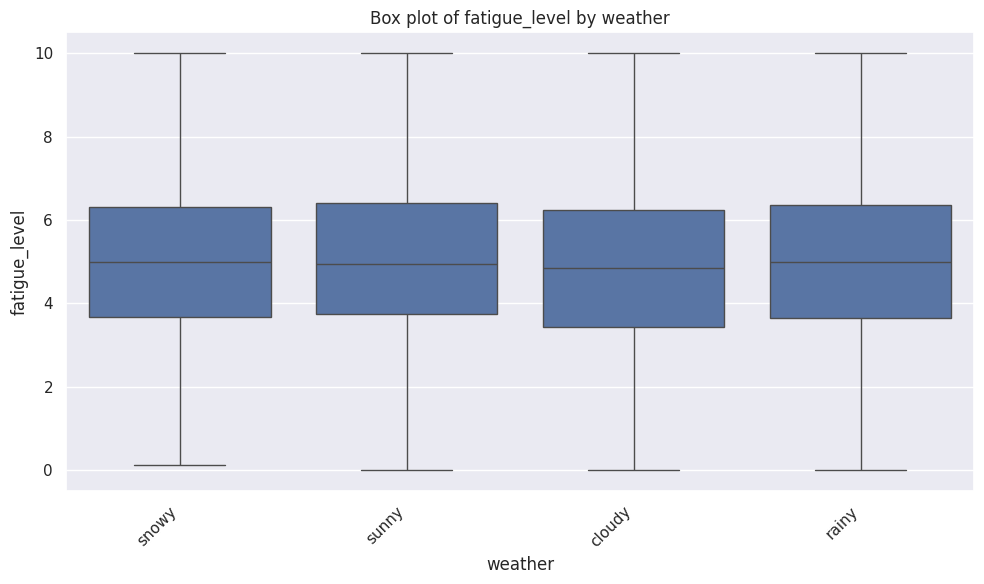

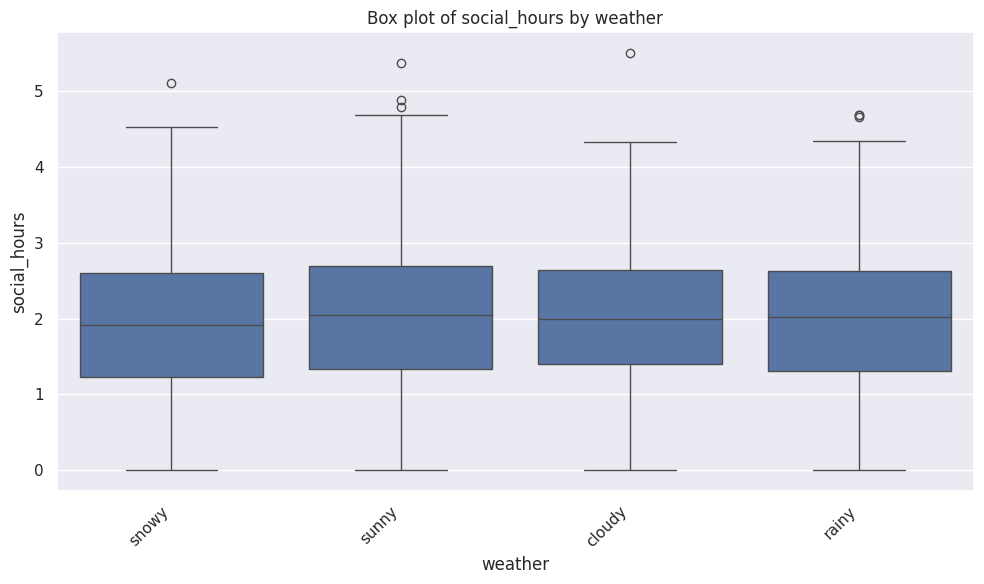

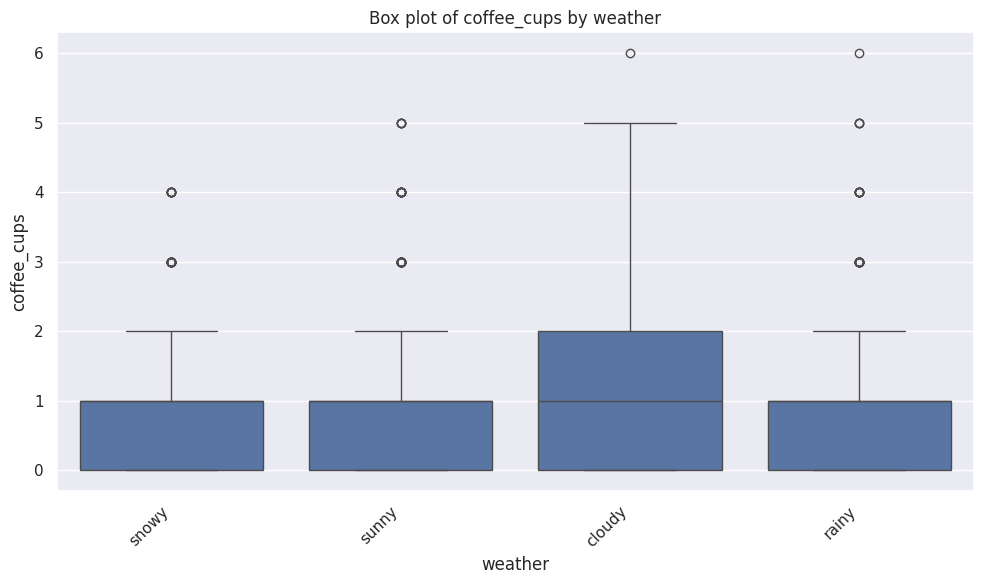

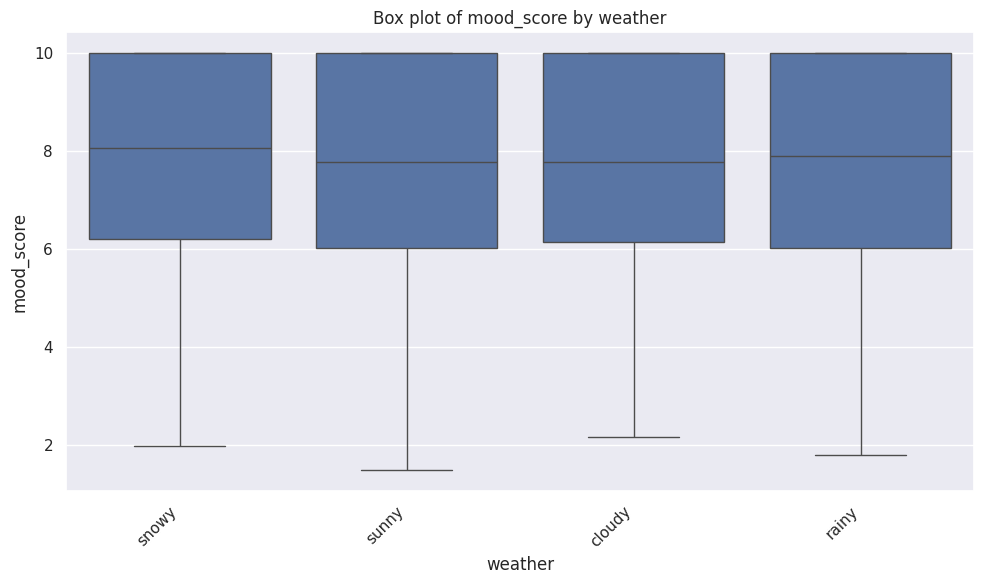

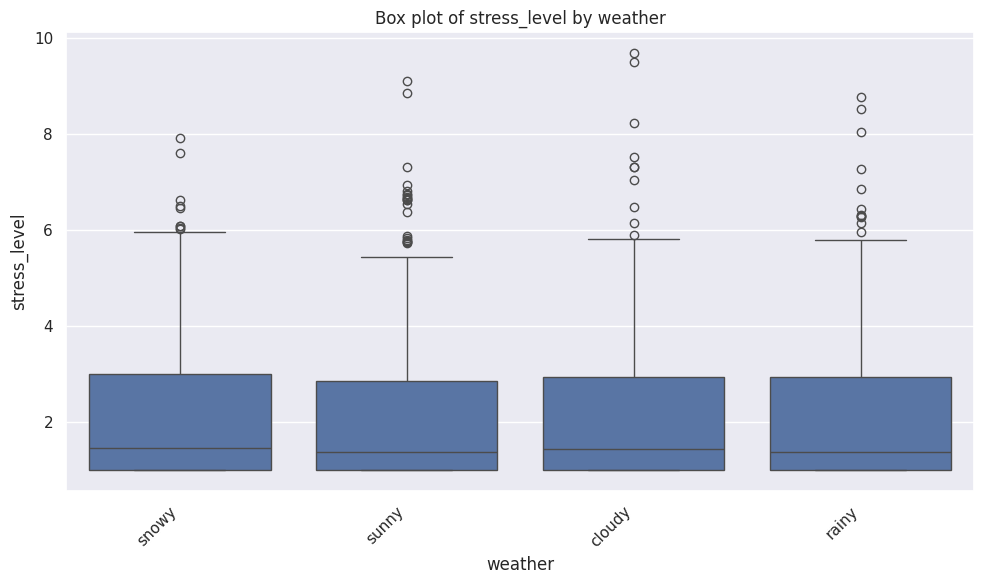

In [17]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

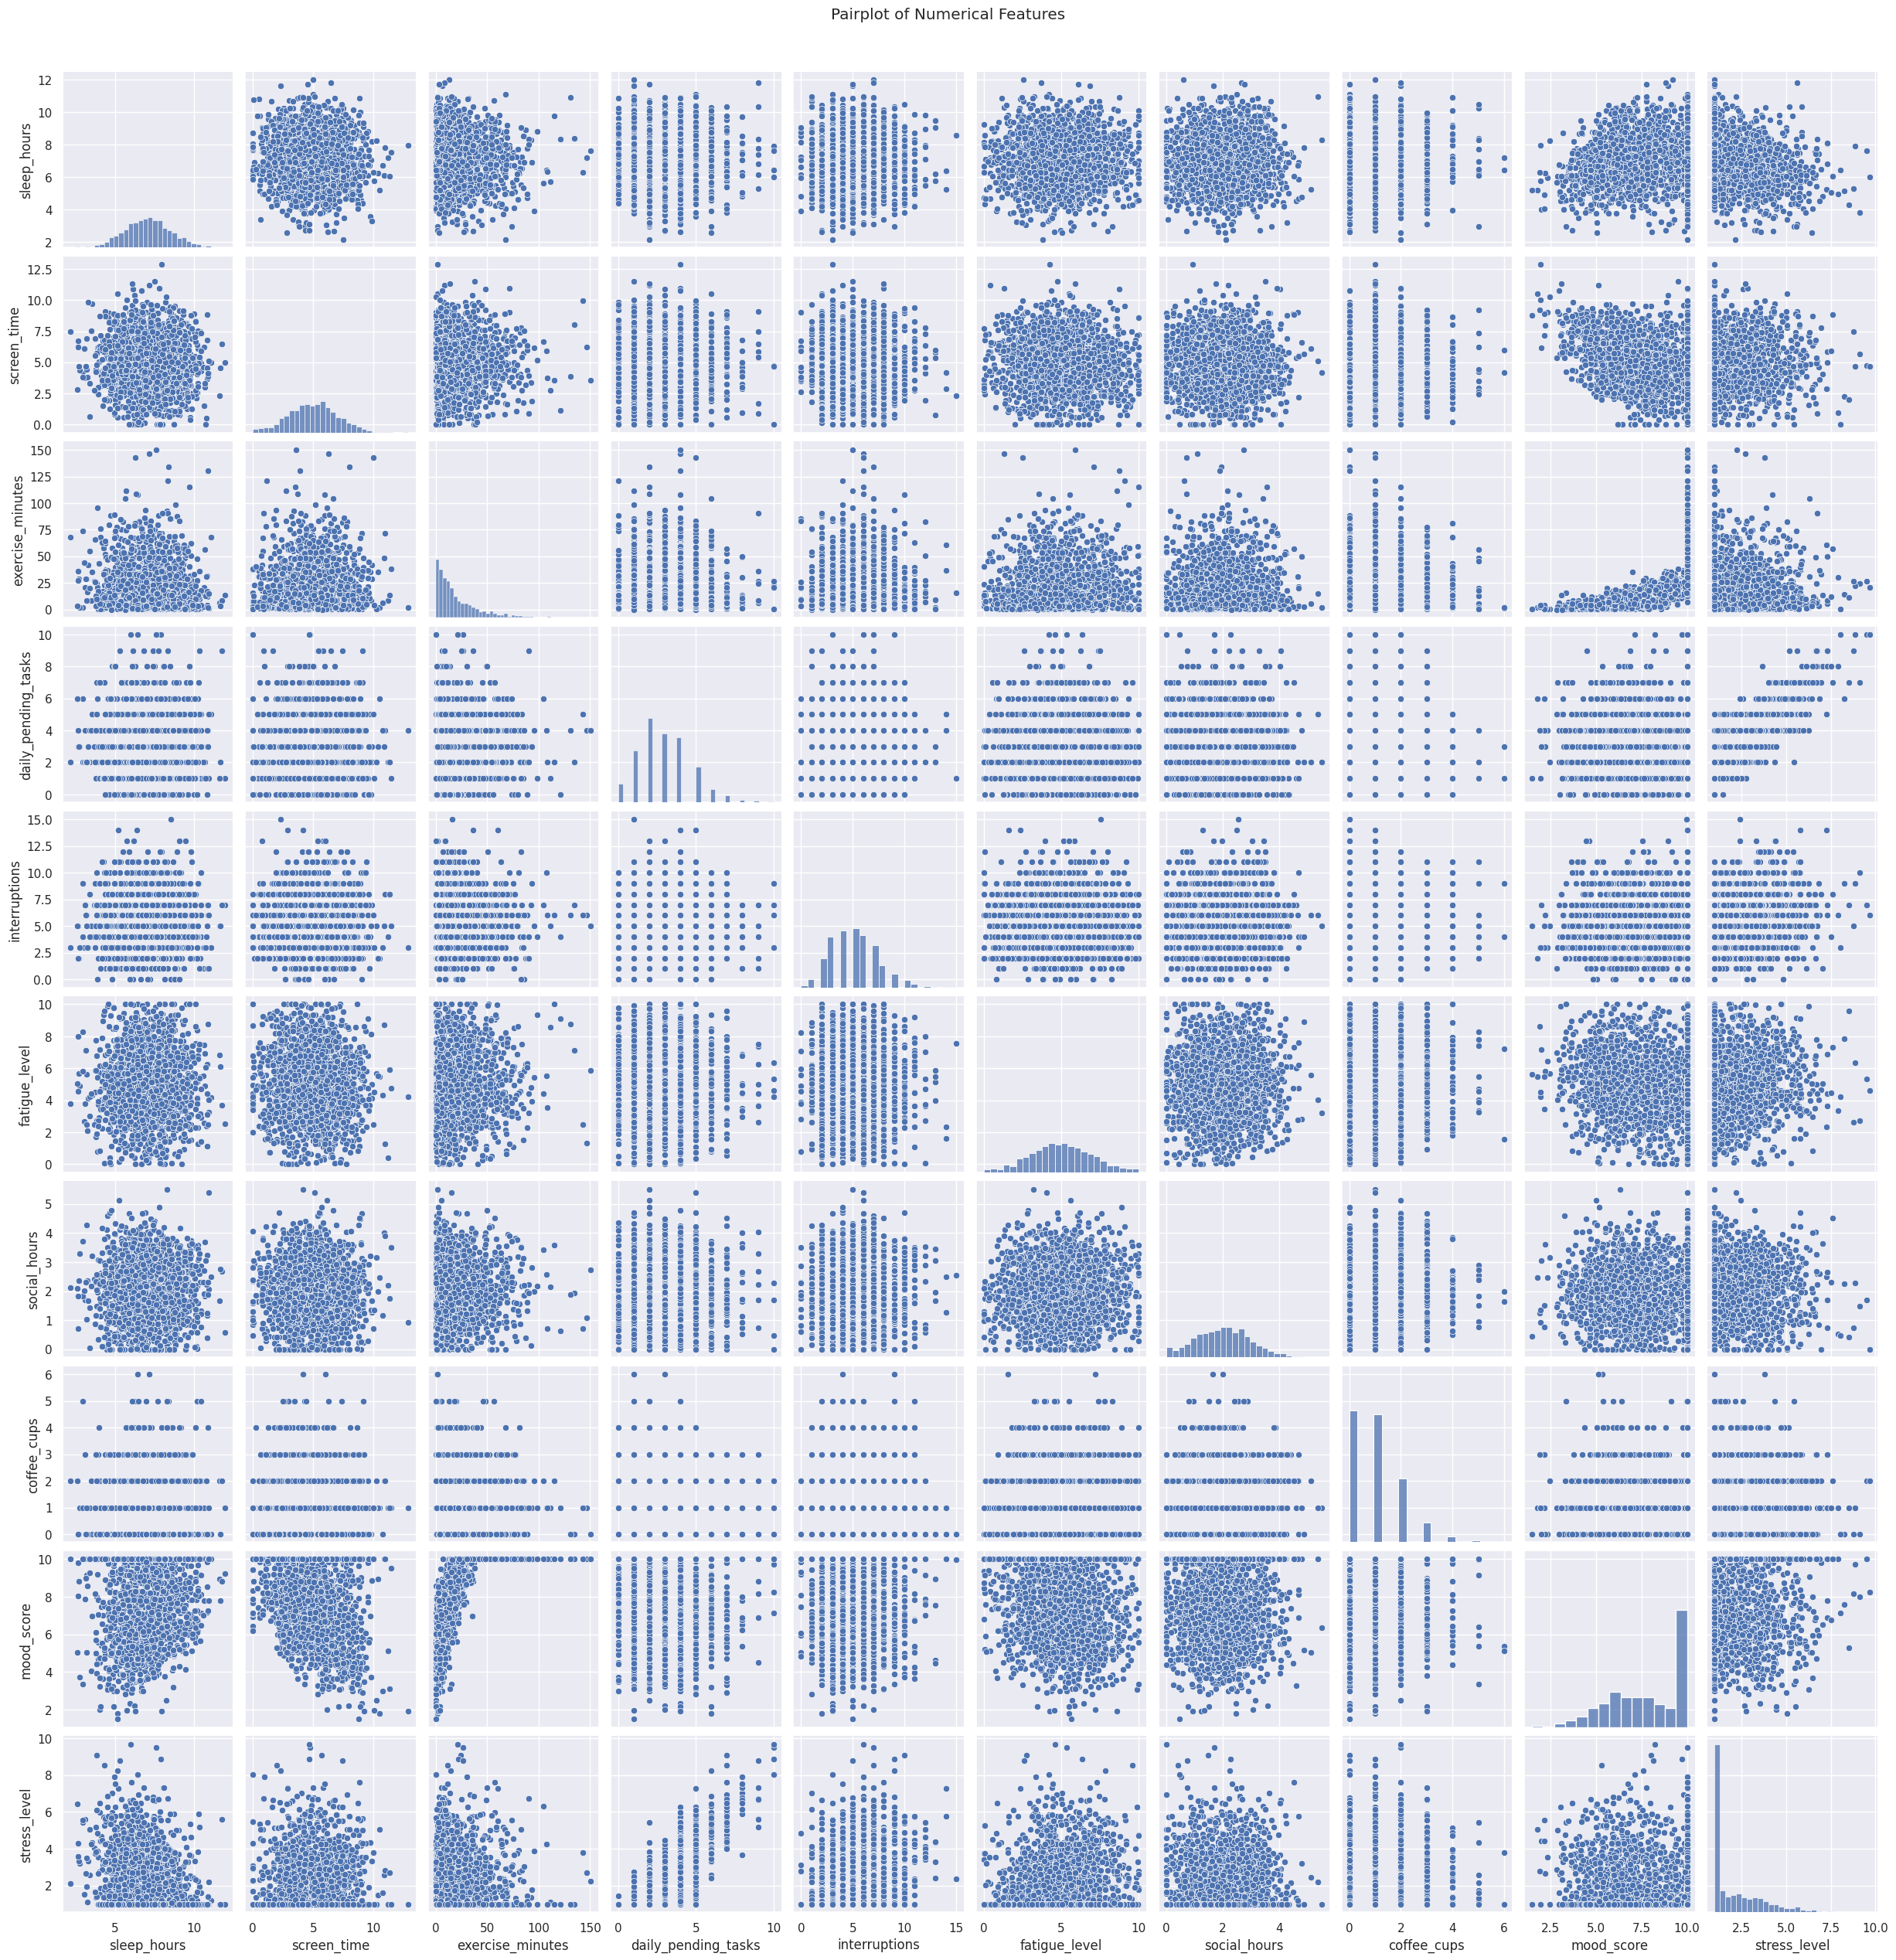

In [20]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

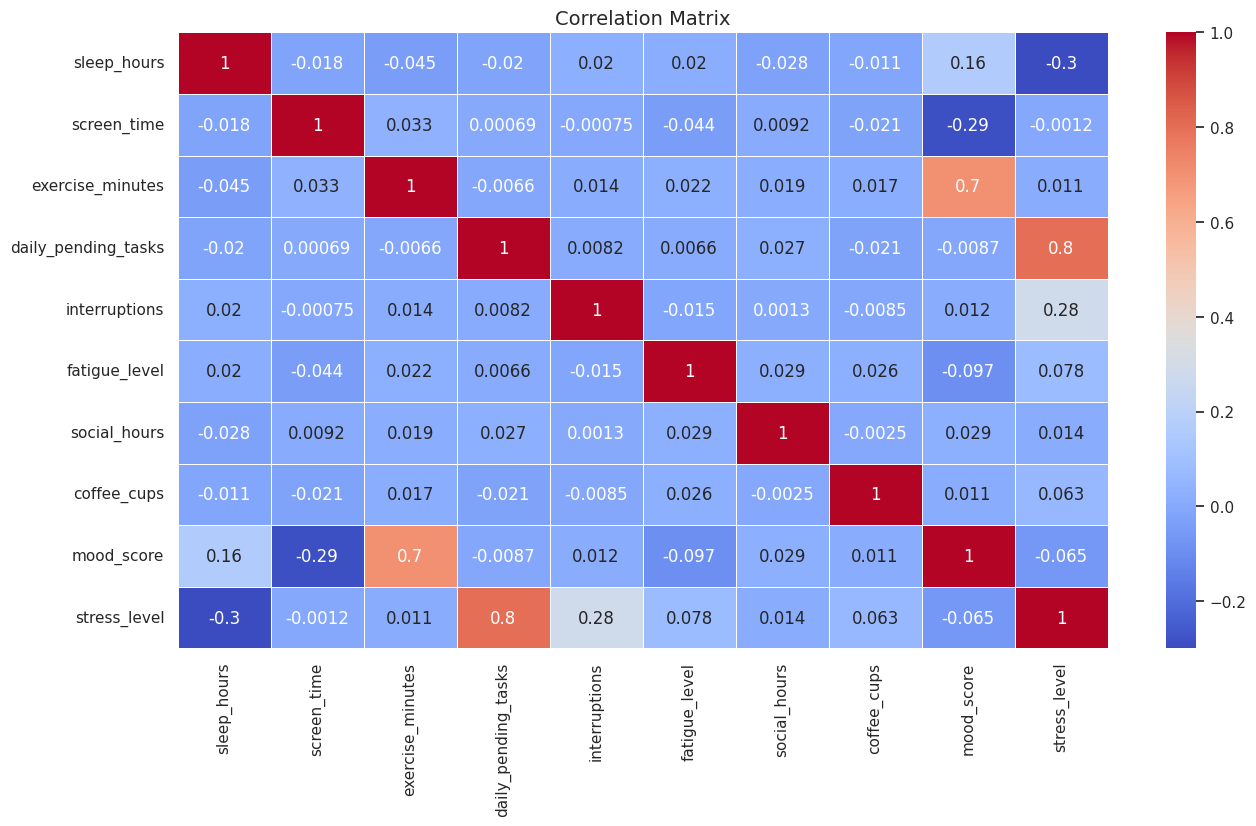

In [19]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You